In [1]:
import sys

def in_colab():
    return "google.colab" in sys.modules

if in_colab():
    print("Running in Google Colab")
    %pip install -q pandas_datareader plotly "kaleido>=1.0.0"
else:
    print("Running in Jupyter / local environment")
    %pip install pandas_datareader plotly "kaleido>=1.0.0"

Running in Jupyter / local environment
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from pandas_datareader import data as web
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LassoCV, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

file_path = "Data.xlsx"

## Data Cleaning and Analysis

In [3]:
# Renewable Production

prod_raw = pd.read_excel(file_path, sheet_name="U.S. Renewable Productio Annual")
prod_df = prod_raw.iloc[7:].copy()

prod_df = prod_df.rename(columns={
    prod_df.columns[0]: "Year",
    "SEDS.GEPRB.US.A": "Geothermal_Prod",
    "SEDS.HYPRB.US.A": "Hydroelectric_Prod",
    "SEDS.SOPRB.US.A": "Solar_Prod",
    "SEDS.WYPRB.US.A": "Wind_Prod",
    "SEDS.BFPRB.US.A": "Biofuels_Prod",
    "SEDS.WWPRB.US.A": "WoodWaste_Prod"
})

prod_keep = [
    "Year",
    "Geothermal_Prod",
    "Hydroelectric_Prod",
    "Solar_Prod",
    "Wind_Prod",
    "Biofuels_Prod",
    "WoodWaste_Prod"
]

prod_df = prod_df[prod_keep].copy()

prod_df["Year"] = pd.to_numeric(prod_df["Year"], errors="coerce")

for col in prod_keep[1:]:
    prod_df[col] = pd.to_numeric(prod_df[col], errors="coerce")

prod_df = prod_df.dropna(subset=["Year"]).sort_values("Year").reset_index(drop=True)
prod_df["Year"] = prod_df["Year"].astype(int)

prod_df["Renewable_Production_Total"] = prod_df[prod_keep[1:]].sum(axis=1)

print(prod_df.shape)
print(prod_df.head())
print(prod_df.tail())
prod_df.isnull().sum()

(64, 8)
   Year  Geothermal_Prod  Hydroelectric_Prod  Solar_Prod  Wind_Prod  \
0  1960              321              530691           0          0   
1  1961              343              586917           0          0   
2  1962              573              576594           0          0   
3  1963              695              615189           0          0   
4  1964              646              672111           0          0   

   Biofuels_Prod  WoodWaste_Prod  Renewable_Production_Total  
0            0.0       1319871.0                   1850883.0  
1            0.0       1294762.0                   1882022.0  
2            0.0       1300242.0                   1877409.0  
3            0.0       1323316.0                   1939200.0  
4            0.0       1336802.0                   2009559.0  
    Year  Geothermal_Prod  Hydroelectric_Prod  Solar_Prod  Wind_Prod  \
59  2019           117716              973355      510570    1153045   
60  2020           118007              8584

Year                          0
Geothermal_Prod               0
Hydroelectric_Prod            0
Solar_Prod                    0
Wind_Prod                     0
Biofuels_Prod                 0
WoodWaste_Prod                0
Renewable_Production_Total    0
dtype: int64

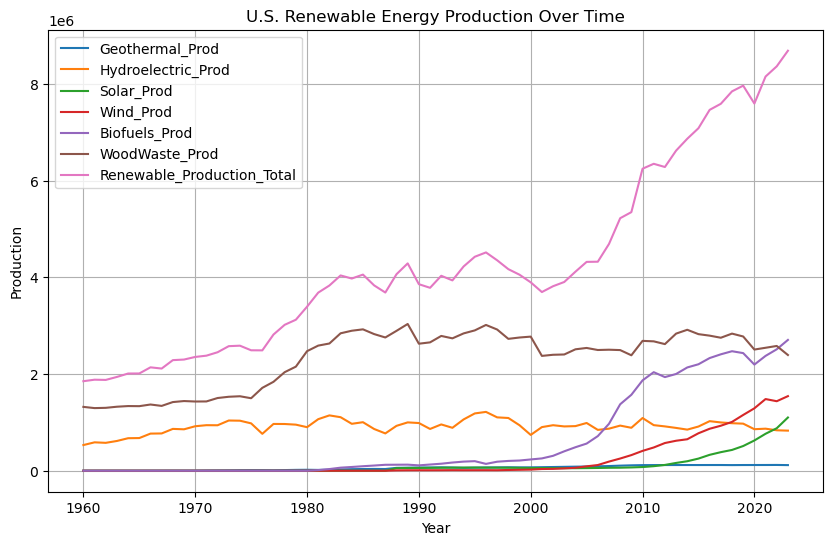

In [4]:
plt.figure(figsize=(10, 6))

exclude_cols = ["Year"]
renewable_cols = [col for col in prod_df.columns if col not in exclude_cols]

for col in renewable_cols:
    plt.plot(prod_df["Year"], prod_df[col], label=col)

plt.title("U.S. Renewable Energy Production Over Time")
plt.xlabel("Year")
plt.ylabel("Production")
plt.legend()
plt.grid(True)

plt.savefig("renewable_production.png", dpi=300, bbox_inches="tight")
plt.show()

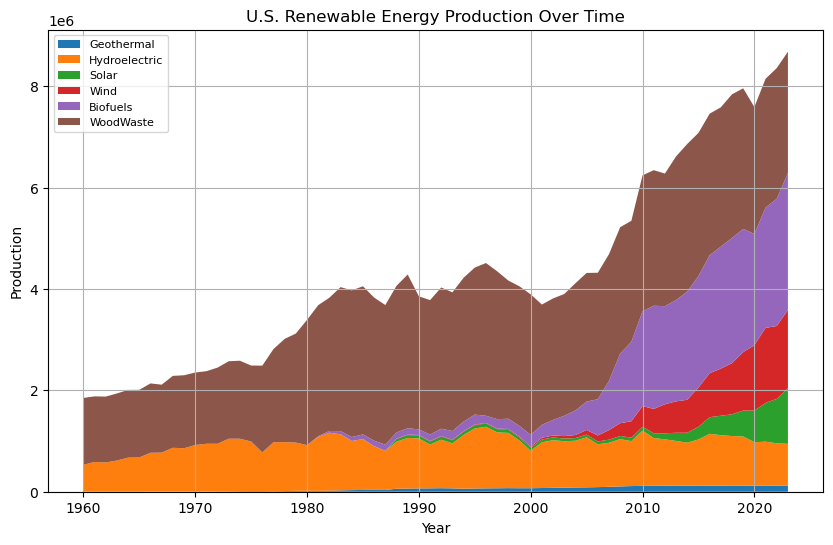

In [5]:
plt.figure(figsize=(10, 6))

exclude_cols = ["Year", "Renewable_Production_Total"]
renewable_cols = [col for col in prod_df.columns if col not in exclude_cols]

plt.stackplot(
    prod_df["Year"],
    *[prod_df[col] for col in renewable_cols],
    labels=[col.replace("_Prod", "") for col in renewable_cols],
)

plt.title("U.S. Renewable Energy Production Over Time")
plt.xlabel("Year")
plt.ylabel("Production")
plt.legend(loc="upper left", fontsize=8)
plt.grid(True)

plt.savefig("renewable_production_stacked.png", dpi=300, bbox_inches="tight")

plt.show()

In [6]:
# Renewable Consumption

cons_raw = pd.read_excel(file_path, sheet_name="U.S. Renewable Consump Annual")
cons_df = cons_raw.iloc[7:].copy()

cons_df = cons_df.rename(columns={
    cons_df.columns[0]: "Year",
    "SEDS.GETCB.US.A": "Geothermal_Cons",
    "SEDS.HYTCB.US.A": "Hydroelectric_Cons",
    "SEDS.SOTCB.US.A": "Solar_Cons",
    "SEDS.WYTCB.US.A": "Wind_Cons",
    "SEDS.BDTCB.US.A": "Biodiesel_Cons",
    "SEDS.EMTCB.US.A": "Ethanol_Cons",
    "SEDS.B1TCB.US.A": "RenewableDiesel_Cons",
    "SEDS.BOTCB.US.A": "OtherBiofuels_Cons",
    "SEDS.WWTCB.US.A": "WoodWaste_Cons"
})

cons_keep = [
    "Year",
    "Geothermal_Cons",
    "Hydroelectric_Cons",
    "Solar_Cons",
    "Wind_Cons",
    "Biodiesel_Cons",
    "Ethanol_Cons",
    "RenewableDiesel_Cons",
    "OtherBiofuels_Cons",
    "WoodWaste_Cons"
]

cons_df = cons_df[cons_keep].copy()
cons_df["Year"] = pd.to_numeric(cons_df["Year"], errors="coerce")

for col in cons_keep[1:]:
    cons_df[col] = pd.to_numeric(cons_df[col], errors="coerce")

cons_df = cons_df.dropna(subset=["Year"]).sort_values("Year").reset_index(drop=True)
cons_df["Year"] = cons_df["Year"].astype(int)

cons_df["Renewable_Consumption_Total"] = cons_df[cons_keep[1:]].sum(axis=1)

print(cons_df.shape)
print(cons_df.head())
print(cons_df.tail())
cons_df.isnull().sum()

(65, 11)
   Year  Geothermal_Cons  Hydroelectric_Cons  Solar_Cons  Wind_Cons  \
0  1960              114              509889           0          0   
1  1961              321              530691           0          0   
2  1962              343              586917           0          0   
3  1963              573              576594           0          0   
4  1964              695              615189           0          0   

   Biodiesel_Cons  Ethanol_Cons  RenewableDiesel_Cons  OtherBiofuels_Cons  \
0               0             0                     0                   0   
1               0             0                     0                   0   
2               0             0                     0                   0   
3               0             0                     0                   0   
4               0             0                     0                   0   

   WoodWaste_Cons  Renewable_Consumption_Total  
0             NaN                     510003.0  
1  

Year                           0
Geothermal_Cons                0
Hydroelectric_Cons             0
Solar_Cons                     0
Wind_Cons                      0
Biodiesel_Cons                 0
Ethanol_Cons                   0
RenewableDiesel_Cons           0
OtherBiofuels_Cons             0
WoodWaste_Cons                 1
Renewable_Consumption_Total    0
dtype: int64

In [7]:
# State-Level Renewable + Non-Renewable Energy Consumption

cons_state_raw = pd.read_excel(file_path, sheet_name="Consumption")

year_cols = [col for col in cons_state_raw.columns if isinstance(col, int)]

energy_codes = {
    # Renewable
    "GETCB": "Geothermal_Cons",
    "HYTCB": "Hydroelectric_Cons",
    "SOTCB": "Solar_Cons",
    "WYTCB": "Wind_Cons",
    "BDTCB": "Biodiesel_Cons",
    "EMTCB": "Ethanol_Cons",
    "B1TCB": "RenewableDiesel_Cons",
    "WWTCB": "WoodWaste_Cons",
    "RETCB": "Renewable_Consumption_Total",

    # Non-renewable
    "CLTCB": "Coal_Cons",
    "NGTCB": "NaturalGas_Cons",
    "PATCB": "Petroleum_Cons",
    "NUETB": "Nuclear_Cons",
    "FFTCB": "FossilFuel_Consumption_Total",

    # Overall total
    "TETCB": "Total_Energy_Consumption"
}

cons_state = cons_state_raw[
    cons_state_raw["MSN"].isin(energy_codes.keys())
].copy()

cons_state_long = cons_state.melt(
    id_vars=["State", "MSN"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Consumption"
)

cons_state_long["Year"] = pd.to_numeric(cons_state_long["Year"], errors="coerce")
cons_state_long["Consumption"] = pd.to_numeric(cons_state_long["Consumption"], errors="coerce")

cons_state_long = cons_state_long.dropna(subset=["Year", "Consumption"])
cons_state_long["Year"] = cons_state_long["Year"].astype(int)

cons_state_long["Energy_Source"] = cons_state_long["MSN"].map(energy_codes)

cons_state_df = cons_state_long.pivot_table(
    index=["State", "Year"],
    columns="Energy_Source",
    values="Consumption",
    aggfunc="sum"
).reset_index()

cons_state_df.columns.name = None

cons_state_df["NonRenewable_Consumption_Total"] = cons_state_df[
    ["Coal_Cons", "NaturalGas_Cons", "Petroleum_Cons", "Nuclear_Cons"]
].sum(axis=1)

cons_state_df["Renewable_Share"] = (
    cons_state_df["Renewable_Consumption_Total"] /
    cons_state_df["Total_Energy_Consumption"]
)

print(cons_state_df.shape)
print(cons_state_df.head())
print(cons_state_df.tail())
print(cons_state_df.isnull().sum())

(3328, 19)
  State  Year  Biodiesel_Cons  Coal_Cons  Ethanol_Cons  \
0    AK  1960             0.0     7189.0           0.0   
1    AK  1961             0.0    11552.0           0.0   
2    AK  1962             0.0    13559.0           0.0   
3    AK  1963             0.0    11999.0           0.0   
4    AK  1964             0.0    12029.0           0.0   

   FossilFuel_Consumption_Total  Geothermal_Cons  Hydroelectric_Cons  \
0                       54633.0              0.0               989.0   
1                       64860.0              0.0              1015.0   
2                       71359.0              0.0              1036.0   
3                       72995.0              0.0              1110.0   
4                       76965.0              0.0              1100.0   

   NaturalGas_Cons  Nuclear_Cons  Petroleum_Cons  RenewableDiesel_Cons  \
0           2034.0           0.0         45410.0                   0.0   
1           2300.0           0.0         51008.0           

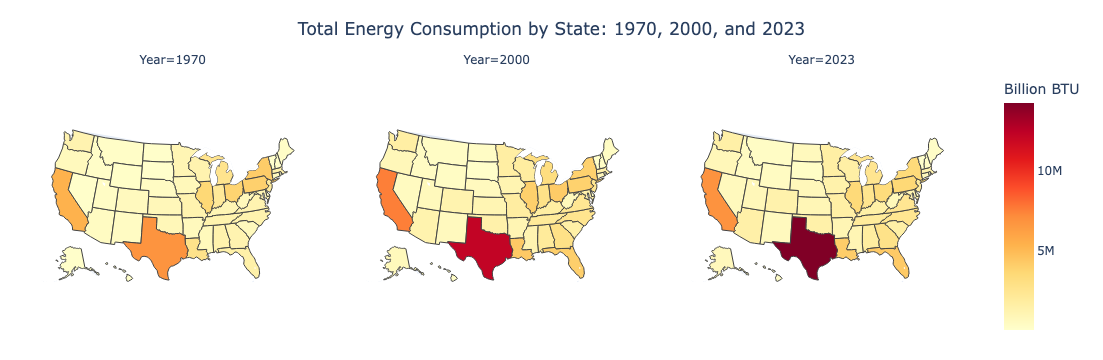

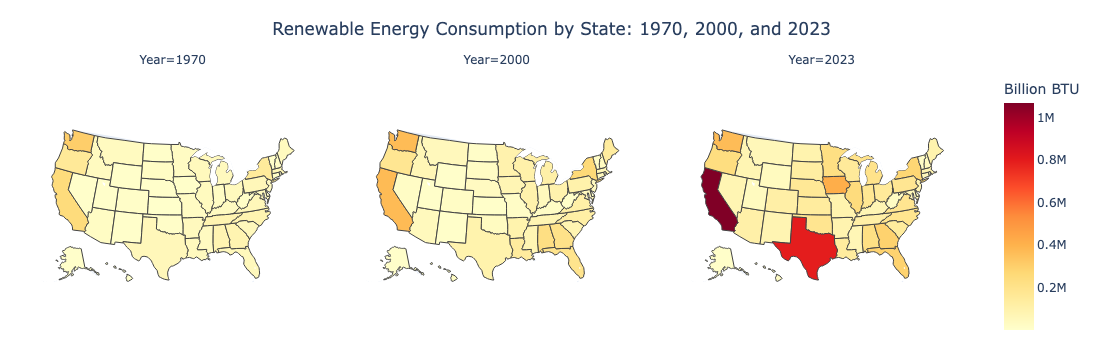

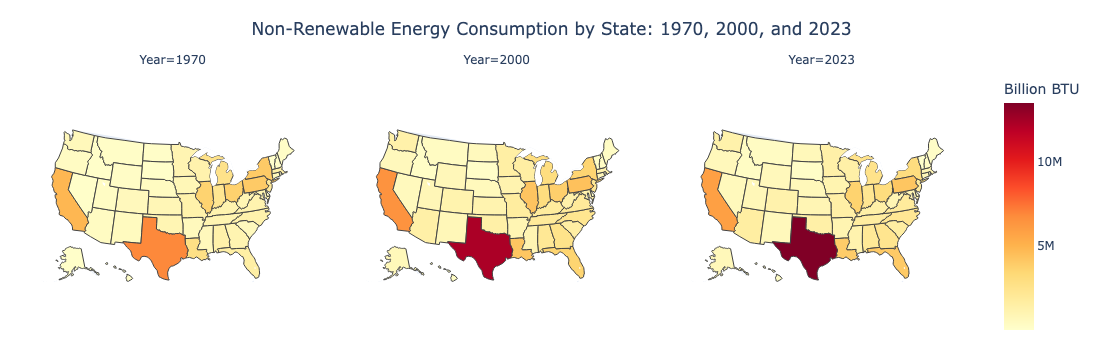

In [8]:
target_heatmap_years = [1970, 2000, 2023]
available_years = sorted(cons_state_df["Year"].dropna().unique())

heatmap_years = []
for year in target_heatmap_years:
    if year in available_years:
        heatmap_years.append(year)

heatmap_years = list(dict.fromkeys(heatmap_years))

state_heatmap_df = cons_state_df[
    cons_state_df["Year"].isin(heatmap_years)
].copy()

# Remove U.S. total rows if they exist
state_heatmap_df = state_heatmap_df[
    ~state_heatmap_df["State"].isin(["US", "USA"])
]

heatmap_metrics = {
    "Total_Energy_Consumption": "Total Energy Consumption",
    "Renewable_Consumption_Total": "Renewable Energy Consumption",
    "NonRenewable_Consumption_Total": "Non-Renewable Energy Consumption"
}

for metric, title in heatmap_metrics.items():
    fig = px.choropleth(
        state_heatmap_df,
        locations="State",
        locationmode="USA-states",
        color=metric,
        scope="usa",
        facet_col="Year",
        facet_col_wrap=3,
        color_continuous_scale="YlOrRd",
        labels={metric: "Billion BTU"},
        title=f"{title} by State: 1970, 2000, and 2023"
    )

    fig.update_layout(
        title_x=0.5,
        margin=dict(l=20, r=20, t=70, b=20),
        coloraxis_colorbar_title="Billion BTU"
    )

    file_name = metric.lower() + "_state_heatmap.png"
    fig.write_image(file_name, width=1800, height=600)
    fig.show()

In [9]:
energy_year_summary = (
    cons_state_df
    .groupby("Year")[[
        "Renewable_Consumption_Total",
        "NonRenewable_Consumption_Total",
        "Total_Energy_Consumption"
    ]]
    .sum()
    .reset_index()
)

print(energy_year_summary)
print(energy_year_summary.tail(20))

    Year  Renewable_Consumption_Total  NonRenewable_Consumption_Total  \
0   1960                    3659748.0                      84191115.0   
1   1961                    3651546.0                      85464245.0   
2   1962                    3775003.0                      89318601.0   
3   1963                    3800966.0                      93032511.0   
4   1964                    3905372.0                      97090511.0   
..   ...                          ...                             ...   
59  2019                   15165961.0                     180772071.0   
60  2020                   14575937.0                     165579494.0   
61  2021                   15282231.0                     174439997.0   
62  2022                   16189222.0                     176642358.0   
63  2023                   16336444.0                     174634394.0   

    Total_Energy_Consumption  
0                 87876183.0  
1                 89123284.0  
2                 93091758.0  

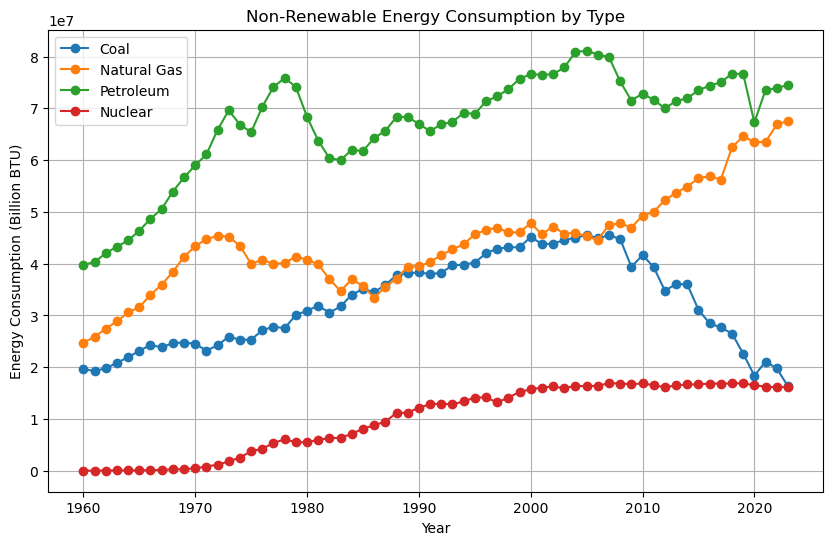

In [10]:
nonrenewable_year_df = (
    cons_state_df
    .groupby("Year")[[
        "Coal_Cons",
        "NaturalGas_Cons",
        "Petroleum_Cons",
        "Nuclear_Cons"
    ]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(nonrenewable_year_df["Year"], nonrenewable_year_df["Coal_Cons"], marker="o", label="Coal")
plt.plot(nonrenewable_year_df["Year"], nonrenewable_year_df["NaturalGas_Cons"], marker="o", label="Natural Gas")
plt.plot(nonrenewable_year_df["Year"], nonrenewable_year_df["Petroleum_Cons"], marker="o", label="Petroleum")
plt.plot(nonrenewable_year_df["Year"], nonrenewable_year_df["Nuclear_Cons"], marker="o", label="Nuclear")

plt.title("Non-Renewable Energy Consumption by Type")
plt.xlabel("Year")
plt.ylabel("Energy Consumption (Billion BTU)")
plt.legend()
plt.grid(True)

# Save figure
plt.savefig("nonrenewable_by_type.png", dpi=300, bbox_inches="tight")

plt.show()

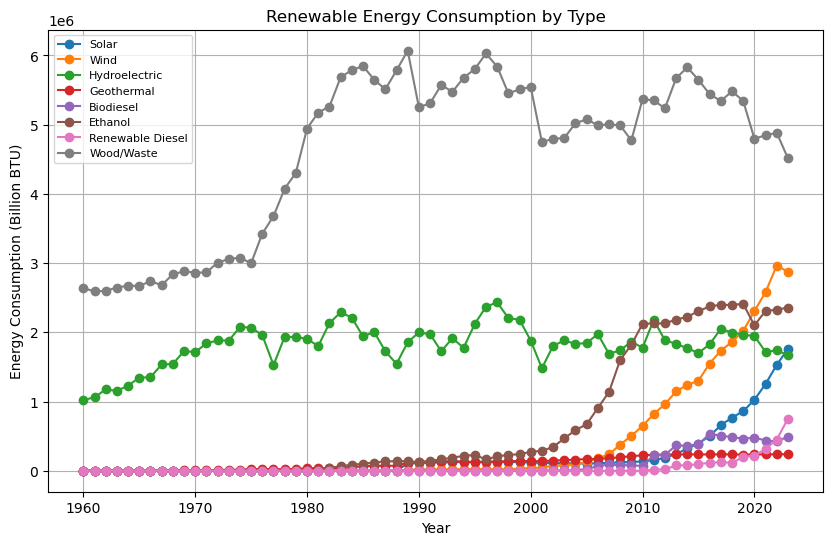

In [11]:
renewable_year_df = (
    cons_state_df
    .groupby("Year")[[
        "Solar_Cons",
        "Wind_Cons",
        "Hydroelectric_Cons",
        "Geothermal_Cons",
        "Biodiesel_Cons",
        "Ethanol_Cons",
        "RenewableDiesel_Cons",
        "WoodWaste_Cons"
    ]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(renewable_year_df["Year"], renewable_year_df["Solar_Cons"], marker="o", label="Solar")
plt.plot(renewable_year_df["Year"], renewable_year_df["Wind_Cons"], marker="o", label="Wind")
plt.plot(renewable_year_df["Year"], renewable_year_df["Hydroelectric_Cons"], marker="o", label="Hydroelectric")
plt.plot(renewable_year_df["Year"], renewable_year_df["Geothermal_Cons"], marker="o", label="Geothermal")
plt.plot(renewable_year_df["Year"], renewable_year_df["Biodiesel_Cons"], marker="o", label="Biodiesel")
plt.plot(renewable_year_df["Year"], renewable_year_df["Ethanol_Cons"], marker="o", label="Ethanol")
plt.plot(renewable_year_df["Year"], renewable_year_df["RenewableDiesel_Cons"], marker="o", label="Renewable Diesel")
plt.plot(renewable_year_df["Year"], renewable_year_df["WoodWaste_Cons"], marker="o", label="Wood/Waste")

plt.title("Renewable Energy Consumption by Type")
plt.xlabel("Year")
plt.ylabel("Energy Consumption (Billion BTU)")
plt.legend(loc="upper left", fontsize=8)
plt.grid(True)

plt.savefig("renewable_by_type.png", dpi=300, bbox_inches="tight")

plt.show()

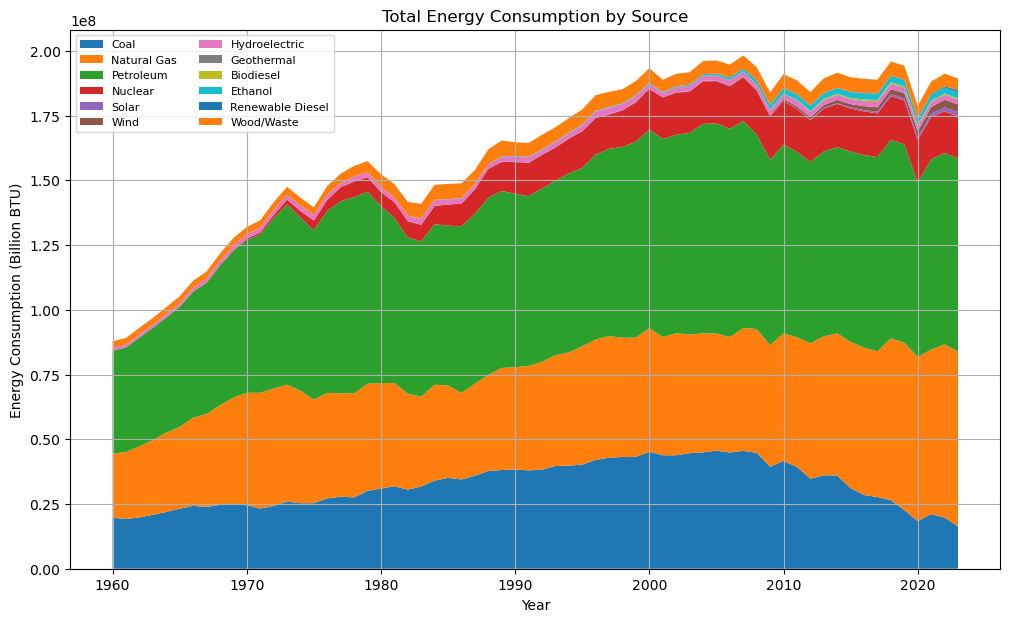

In [12]:
energy_year_df = (
    cons_state_df
    .groupby("Year")[[
        # Non-renewable
        "Coal_Cons",
        "NaturalGas_Cons",
        "Petroleum_Cons",
        "Nuclear_Cons",

        # Renewable
        "Solar_Cons",
        "Wind_Cons",
        "Hydroelectric_Cons",
        "Geothermal_Cons",
        "Biodiesel_Cons",
        "Ethanol_Cons",
        "RenewableDiesel_Cons",
        "WoodWaste_Cons"
    ]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 7))

plt.stackplot(
    energy_year_df["Year"],

    # Non-renewables bottom
    energy_year_df["Coal_Cons"],
    energy_year_df["NaturalGas_Cons"],
    energy_year_df["Petroleum_Cons"],
    energy_year_df["Nuclear_Cons"],

    # Renewables on top
    energy_year_df["Solar_Cons"],
    energy_year_df["Wind_Cons"],
    energy_year_df["Hydroelectric_Cons"],
    energy_year_df["Geothermal_Cons"],
    energy_year_df["Biodiesel_Cons"],
    energy_year_df["Ethanol_Cons"],
    energy_year_df["RenewableDiesel_Cons"],
    energy_year_df["WoodWaste_Cons"],

    labels=[
        "Coal", "Natural Gas", "Petroleum", "Nuclear",
        "Solar", "Wind", "Hydroelectric", "Geothermal",
        "Biodiesel", "Ethanol", "Renewable Diesel", "Wood/Waste"
    ]
)

plt.title("Total Energy Consumption by Source")
plt.xlabel("Year")
plt.ylabel("Energy Consumption (Billion BTU)")
plt.legend(loc="upper left", fontsize=8, ncol=2)
plt.grid(True)

plt.savefig("energy_consumption_stacked.png", dpi=300, bbox_inches="tight")

plt.show()

In [13]:
# National Average Electricity Price

def clean_price_sheet(sheet_name):
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    
    data = raw.iloc[2:].copy()

    if sheet_name == "Total Electric Industry 2010":
        price_col = 21
    else:
        price_col = 25

    data = data.iloc[:, [0, 1, price_col]]
    data.columns = ["Year", "State", "Price_cents_kWh"]

    data["Year"] = pd.to_numeric(data["Year"], errors="coerce")
    data["Price_cents_kWh"] = pd.to_numeric(data["Price_cents_kWh"], errors="coerce")

    data = data.dropna(subset=["Year", "State", "Price_cents_kWh"]).copy()
    data["Year"] = data["Year"].astype(int)
    return data

price_1960 = clean_price_sheet("Total Electric Industry 1960")
price_1990 = clean_price_sheet("Total Electric Industry 1990")
price_2010 = clean_price_sheet("Total Electric Industry 2010")

price_df = pd.concat([price_1960, price_1990, price_2010], ignore_index=True)

avg_price_table = (
    price_df.groupby("Year", as_index=False)["Price_cents_kWh"]
    .mean()
    .rename(columns={"Price_cents_kWh": "Avg_Electricity_Price"})
    .sort_values("Year")
)

print(avg_price_table.shape)
print(avg_price_table)
avg_price_table.isnull().sum()

(55, 2)
    Year  Avg_Electricity_Price
0   1970               1.772500
1   1971               1.857308
2   1972               1.953846
3   1973               2.044808
4   1974               2.531923
5   1975               2.930769
6   1976               3.105769
7   1977               3.405000
8   1978               3.677500
9   1979               3.975385
10  1980               4.684615
11  1981               5.465769
12  1982               6.036923
13  1983               6.188462
14  1984               6.233269
15  1985               6.377308
16  1986               6.373654
17  1987               6.321154
18  1988               6.279038
19  1989               6.338654
20  1990               6.475577
21  1991               6.648654
22  1992               6.737500
23  1993               6.882308
24  1994               6.891731
25  1995               6.911923
26  1996               6.912115
27  1997               6.910769
28  1998               6.829615
29  1999               6.718462


Year                     0
Avg_Electricity_Price    0
dtype: int64

In [14]:
# State Electricity Price
import seaborn as sns

state_price_table = (
    price_df.pivot_table(
        index="Year",
        columns="State",
        values="Price_cents_kWh",
        aggfunc="mean"
    )
    .sort_index()
)

print(state_price_table.shape)
print(state_price_table.head())
print(state_price_table.tail())
state_price_table.isnull().sum()

(55, 52)
State    AK    AL    AR    AZ    CA    CO    CT    DC    DE    FL  ...    TN  \
Year                                                               ...         
1970   3.06  1.19  1.62  1.82  1.59  2.06  2.14  1.84  1.65  1.93  ...  0.97   
1971   3.11  1.29  1.68  1.85  1.67  2.07  2.32  2.00  1.89  1.99  ...  1.15   
1972   3.37  1.35  1.77  1.98  1.79  2.15  2.59  2.11  2.22  2.09  ...  1.14   
1973   3.20  1.53  1.85  2.16  1.95  2.20  2.81  2.26  2.44  2.25  ...  1.20   
1974   3.26  1.84  2.32  2.60  2.64  2.39  3.99  3.29  3.44  3.01  ...  1.45   

State    TX    US    UT    VA    VT    WA    WI    WV    WY  
Year                                                         
1970   1.48  1.68  1.76  1.66  2.06  0.67  2.04  1.35  1.48  
1971   1.50  1.78  1.84  1.72  2.12  0.70  2.09  1.50  1.50  
1972   1.54  1.86  1.87  1.80  2.34  0.72  2.22  1.63  1.54  
1973   1.60  1.97  1.88  1.90  2.50  0.76  2.38  1.68  1.50  
1974   1.91  2.50  2.02  2.60  3.13  0.79  2.62  2.18  1.5

State
AK    0
AL    0
AR    0
AZ    0
CA    0
CO    0
CT    0
DC    0
DE    0
FL    0
GA    0
HI    0
IA    0
ID    0
IL    0
IN    0
KS    0
KY    0
LA    0
MA    0
MD    0
ME    0
MI    0
MN    0
MO    0
MS    0
MT    0
NC    0
ND    0
NE    0
NH    0
NJ    0
NM    0
NV    0
NY    0
OH    0
OK    0
OR    0
PA    0
RI    0
SC    0
SD    0
TN    0
TX    0
US    0
UT    0
VA    0
VT    0
WA    0
WI    0
WV    0
WY    0
dtype: int64

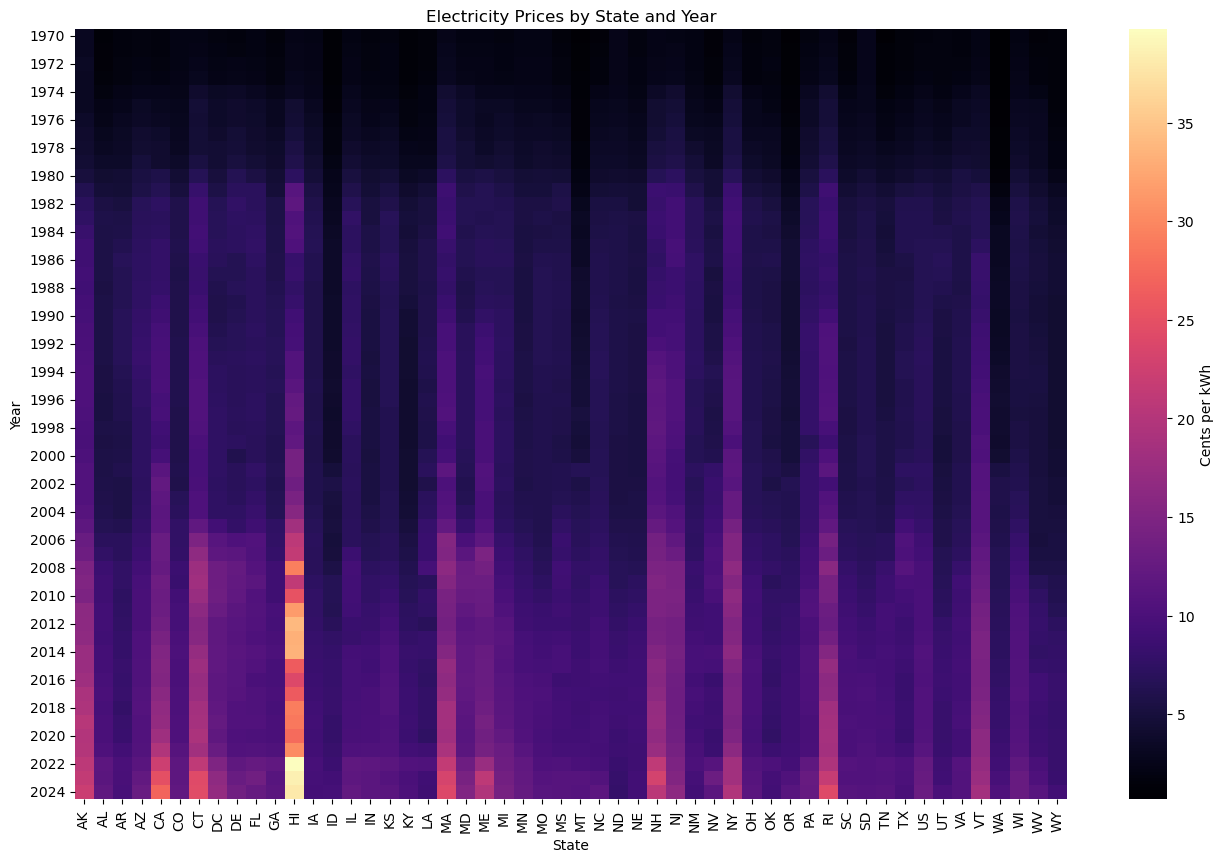

In [15]:
# Electricity Prices Heatmap

plt.figure(figsize=(16, 10))
ax = sns.heatmap(state_price_table, cmap="magma")

plt.title("Electricity Prices by State and Year")
plt.xlabel("State")
plt.ylabel("Year")

cbar = ax.collections[0].colorbar
cbar.set_label("Cents per kWh")

plt.savefig("state_electricity_price_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

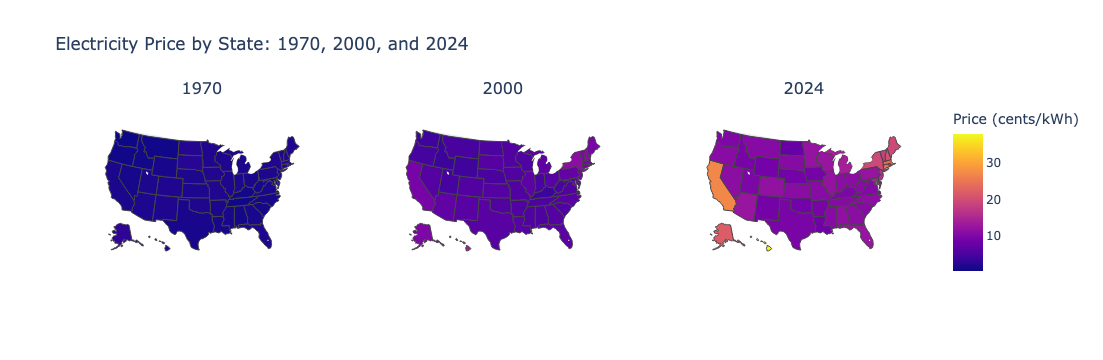

In [16]:
price_df["Year"] = price_df["Year"].astype(int)

years = [1970, 2000, 2024]

vmin = price_df["Price_cents_kWh"].min()
vmax = price_df["Price_cents_kWh"].max()

fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=[str(y) for y in years]
)

for i, year in enumerate(years):
    map_df = price_df[price_df["Year"] == year]

    choropleth = px.choropleth(
        map_df,
        locations="State",
        locationmode="USA-states",
        facet_col="Year",
        facet_col_wrap=3,
        color="Price_cents_kWh",
        color_continuous_scale="magma",
        range_color=(vmin, vmax)
    )

    for trace in choropleth.data:
        fig.add_trace(trace, row=1, col=i+1)

fig.update_layout(
    title_text="Electricity Price by State: 1970, 2000, and 2024",
    coloraxis=dict(colorbar_title="Price (cents/kWh)")
)

fig.update_geos(scope="usa")

fig.write_image("electricity_maps_combined.png", width=1800, height=600)
fig.show()

In [17]:
# Total CO2 Emissions by Energy Source

emissions_df = pd.read_excel(file_path, sheet_name="Emissions")

co2_source_df = emissions_df[
    (emissions_df["State"] == "US-TOTAL") &
    (emissions_df["Producer Type"] == "Total Electric Power Industry")
][["Year", "Energy Source", "CO2\n(Metric Tons)"]].copy()

co2_source_df = co2_source_df.rename(columns={
    "CO2\n(Metric Tons)": "CO2"
})

co2_source_df = co2_source_df.dropna().reset_index(drop=True)
co2_source_df["Year"] = co2_source_df["Year"].astype(int)

print(co2_source_df.shape)
print(co2_source_df.head(6))
print(co2_source_df.tail(9))
co2_source_df.isnull().sum()

(300, 3)
   Year Energy Source         CO2
0  1990   All Sources  1953698942
1  1990          Coal  1592394845
2  1990    Geothermal      383992
3  1990   Natural Gas   233851696
4  1990         Other     7488350
5  1990     Petroleum   119580059
     Year                Energy Source         CO2
291  2024                  All Sources  1537072640
292  2024                         Coal   686354372
293  2024                   Geothermal      405615
294  2024                  Natural Gas   820609513
295  2024                Other Biomass           0
296  2024                  Other Gases           0
297  2024                        Other    13428677
298  2024                    Petroleum    16274463
299  2024  Wood and Wood Derived Fuels           0


Year             0
Energy Source    0
CO2              0
dtype: int64

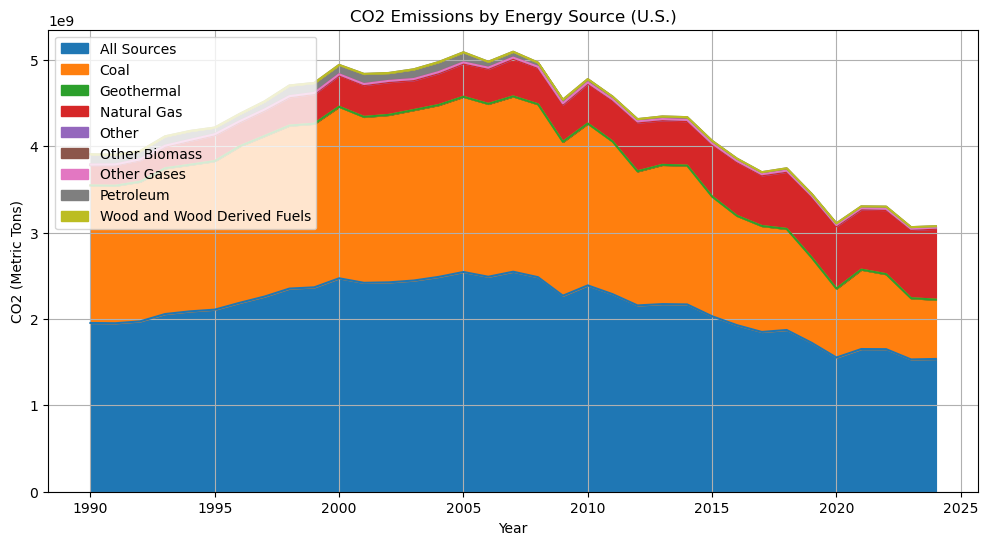

In [18]:
co2_pivot = co2_source_df.pivot_table(
    index="Year",
    columns="Energy Source",
    values="CO2",
    aggfunc="sum"
).fillna(0)

co2_pivot.plot(kind="area", figsize=(12, 6))

plt.title("CO2 Emissions by Energy Source (U.S.)")
plt.xlabel("Year")
plt.ylabel("CO2 (Metric Tons)")
plt.legend(loc="upper left")
plt.grid(True)

plt.savefig(f"co2_emissions_by_source.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# CO2 Emission by State

co2_state_df = emissions_df[
    (emissions_df["Producer Type"] == "Total Electric Power Industry") &
    (emissions_df["Energy Source"] == "All Sources")
][["Year", "State", "CO2\n(Metric Tons)"]].copy()

co2_state_df = co2_state_df.rename(columns={
    "CO2\n(Metric Tons)": "CO2"
})

co2_state_df = co2_state_df.dropna().reset_index(drop=True)
co2_state_df["Year"] = co2_state_df["Year"].astype(int)

print(co2_state_df.shape)
print(co2_state_df.head(52))
print(co2_state_df.tail(52))
co2_state_df.isnull().sum()

(1820, 3)
    Year     State         CO2
0   1990        AK     4208809
1   1990        AL    52936063
2   1990        AR    23425802
3   1990        AZ    33111213
4   1990        CA    52655643
5   1990        CO    31517085
6   1990        CT    12103268
7   1990        DC      409724
8   1990        DE     8884879
9   1990        FL    91555237
10  1990        GA    67852693
11  1990        HI     8063505
12  1990        IA    29954105
13  1990        ID      489043
14  1990        IL    60761615
15  1990        IN    99078594
16  1990        KS    27517046
17  1990        KY    66691156
18  1990        LA    44982915
19  1990        MA    27815932
20  1990        MD    27349665
21  1990        ME     5204666
22  1990        MI    71755088
23  1990        MN    31917079
24  1990        MO    48705027
25  1990        MS    14776544
26  1990        MT    16129041
27  1990        NC    48999877
28  1990        ND    28488254
29  1990        NE    13557583
30  1990        NH     508674

Year     0
State    0
CO2      0
dtype: int64

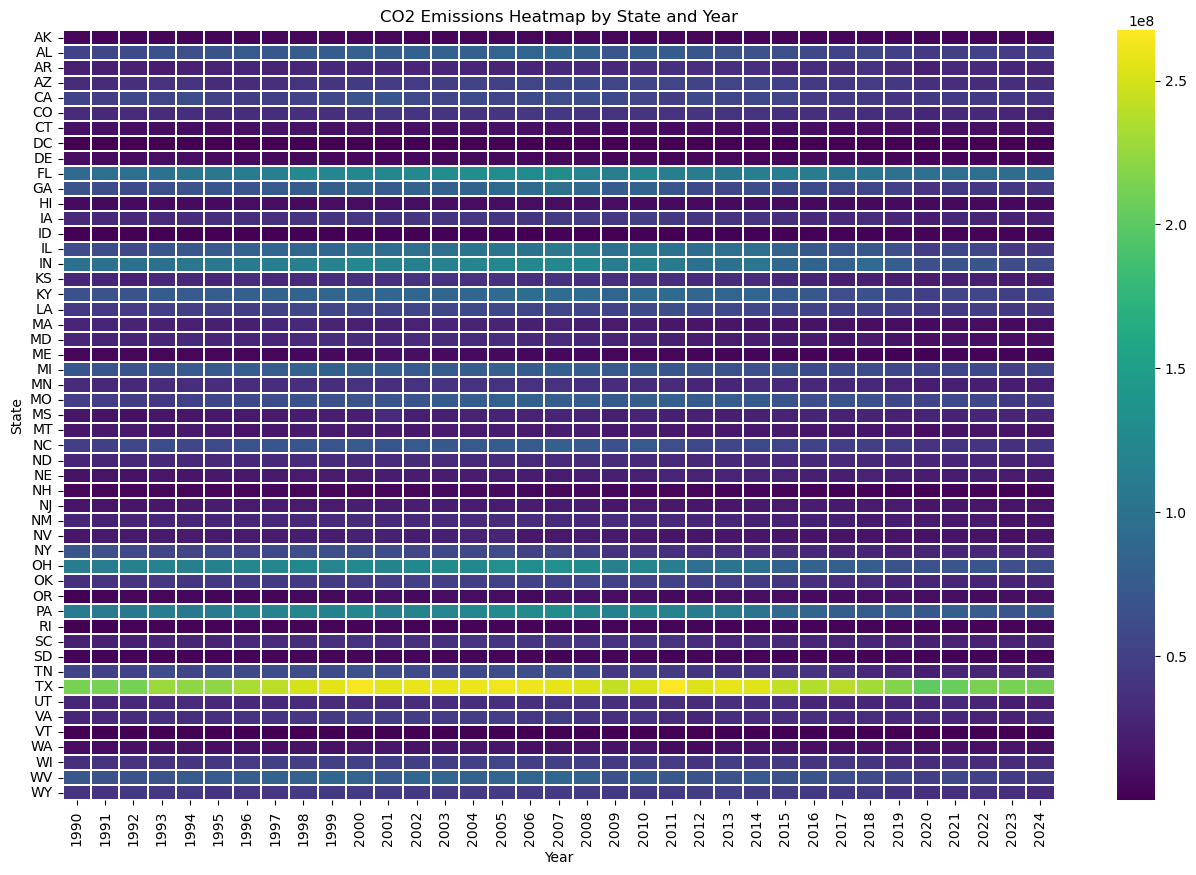

In [20]:
co2_pivot_state = co2_state_df.pivot_table(
    index="State",
    columns="Year",
    values="CO2",
    aggfunc="sum"
)

co2_pivot_state = co2_pivot_state.drop(index="US-TOTAL", errors="ignore")

plt.figure(figsize=(16, 10))

sns.heatmap(
    co2_pivot_state,
    cmap="viridis",
    linewidths=0.3
)

plt.title("CO2 Emissions Heatmap by State and Year")
plt.xlabel("Year")
plt.ylabel("State")

plt.savefig(f"co2_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

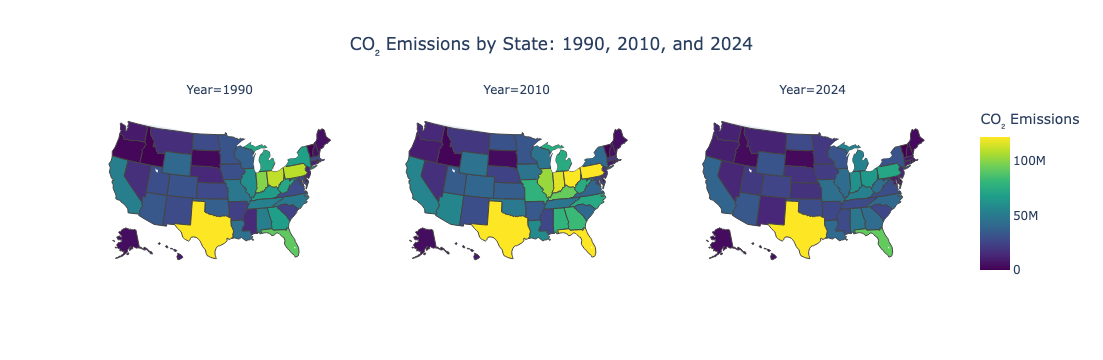

In [21]:
years = [1990, 2010, 2024]

co2_multi = co2_state_df[
    co2_state_df["Year"].isin(years)
].copy()

# Remove U.S. total rows if exists
co2_multi = co2_multi[
    ~co2_multi["State"].isin(["US", "USA", "United States"])
]

# Better scaling: cap color range at 95th percentile
vmin = co2_multi["CO2"].min()
vmax = co2_multi["CO2"].quantile(0.95)

fig = px.choropleth(
    co2_multi,
    locations="State",
    locationmode="USA-states",
    color="CO2",
    scope="usa",
    facet_col="Year",
    facet_col_wrap=3,
    title="CO₂ Emissions by State: 1990, 2010, and 2024",
    color_continuous_scale="viridis",
    labels={"CO2": "CO₂ Emissions"},
    range_color=(vmin, vmax)
)

fig.update_layout(
    title_x=0.5,
    coloraxis_colorbar_title="CO₂ Emissions"
)

fig.write_image("co2_maps_combined.png", width=1800, height=600)

fig.show()

In [22]:
# Top 10 states by electricity price and CO2 level
latest_price_year = int(price_df["Year"].max())
latest_co2_year = int(co2_state_df.loc[co2_state_df["State"] != "US-TOTAL", "Year"].max())

top10_price_states = (
    price_df.loc[price_df["Year"] == latest_price_year, ["Year", "State", "Price_cents_kWh"]]
    .dropna(subset=["State", "Price_cents_kWh"])
    .sort_values("Price_cents_kWh", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10_co2_states = (
    co2_state_df.loc[
        (co2_state_df["Year"] == latest_co2_year) &
        (co2_state_df["State"] != "US-TOTAL"),
        ["Year", "State", "CO2"]
    ]
    .dropna(subset=["State", "CO2"])
    .sort_values("CO2", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print(f"Top 10 states by electricity price in {latest_price_year}")
display(top10_price_states)

print(f"Top 10 states by CO2 emissions in {latest_co2_year}")
display(top10_co2_states)

Top 10 states by electricity price in 2024


,Year,State,Price_cents_kWh
0,2024,HI,38.00
1,2024,CA,27.04
2,2024,CT,24.37
3,2024,RI,24.15
4,2024,MA,23.94
5,2024,AK,22.17
6,2024,NH,20.61
7,2024,NY,19.66
8,2024,ME,19.66
9,2024,VT,18.41


Top 10 states by CO2 emissions in 2024


,Year,State,CO2
0,2024,TX,211902412
1,2024,FL,92505102
2,2024,PA,72323001
3,2024,OH,65214146
4,2024,IN,61437298
5,2024,MI,54012311
6,2024,KY,53086262
7,2024,AL,48516503
8,2024,MO,44270496
9,2024,WV,43966578


## Renewable Energy Relationship Analysis (Production and Consumption)

In [23]:
energy_df = pd.merge(
    prod_df[["Year", "Renewable_Production_Total"]],
    cons_df[["Year", "Renewable_Consumption_Total"]],
    on="Year",
    how="inner"
)

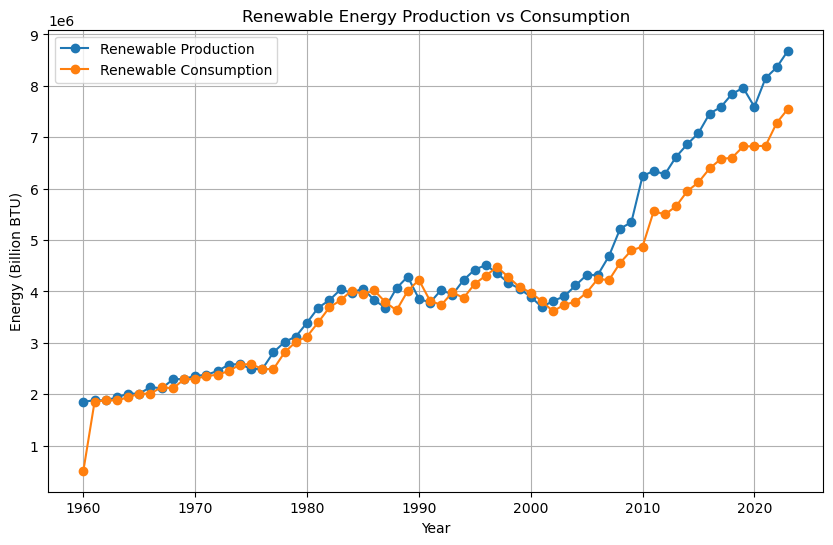

In [24]:
plt.figure(figsize=(10, 6))

# Production
plt.plot(
    energy_df["Year"],
    energy_df["Renewable_Production_Total"],
    marker="o",
    label="Renewable Production"
)

# Consumption
plt.plot(
    energy_df["Year"],
    energy_df["Renewable_Consumption_Total"],
    marker="o",
    label="Renewable Consumption"
)

plt.title("Renewable Energy Production vs Consumption")
plt.xlabel("Year")
plt.ylabel("Energy (Billion BTU)")
plt.legend()
plt.grid(True)

plt.savefig("renewable_production_vs_consumption.png", dpi=300, bbox_inches="tight")
plt.show()

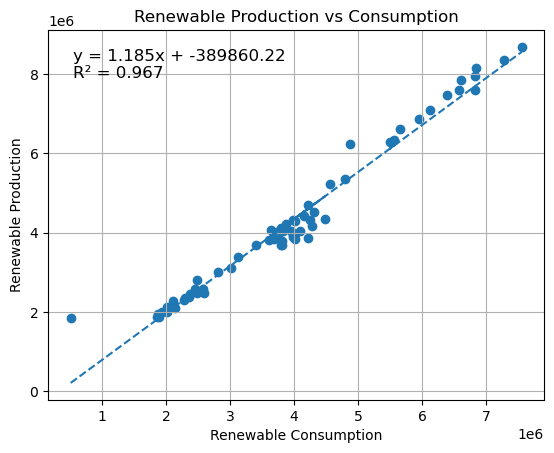

In [25]:
z = np.polyfit(
    energy_df["Renewable_Consumption_Total"],
    energy_df["Renewable_Production_Total"],
    1
)

slope = z[0]
intercept = z[1]

p = np.poly1d(z)

y_pred = p(energy_df["Renewable_Consumption_Total"])

r2 = r2_score(
    energy_df["Renewable_Production_Total"],
    y_pred
)

# Scatter
plt.scatter(
    energy_df["Renewable_Consumption_Total"],
    energy_df["Renewable_Production_Total"]
)

# Trend line
plt.plot(
    energy_df["Renewable_Consumption_Total"],
    p(energy_df["Renewable_Consumption_Total"]),
    linestyle="--"
)

plt.xlabel("Renewable Consumption")
plt.ylabel("Renewable Production")
plt.title("Renewable Production vs Consumption")
plt.grid(True)

plt.text(
    0.05, 0.95,
    f"y = {slope:.3f}x + {intercept:.2f}\nR² = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.savefig("renewable_consumption_vs_production_trend.png", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
corr = energy_df[[
    "Renewable_Production_Total",
    "Renewable_Consumption_Total"
]].corr()

print(corr)

                             Renewable_Production_Total  \
Renewable_Production_Total                     1.000000   
Renewable_Consumption_Total                    0.983508   

                             Renewable_Consumption_Total  
Renewable_Production_Total                      0.983508  
Renewable_Consumption_Total                     1.000000  


## ML Datasets and Correlation Analysis

### Electricity Prices

In [27]:
# ML Electrical Prices Datset

cpi = web.DataReader("CPIAUCSL", "fred", start="1960-01-01", end="2024-12-31")
cpi = cpi.reset_index()
cpi["Year"] = cpi["DATE"].dt.year

cpi_yearly = (
    cpi.groupby("Year", as_index=False)["CPIAUCSL"]
       .mean()
       .rename(columns={"CPIAUCSL": "CPI"})
)

base_year = 2024
base_cpi = cpi_yearly.loc[cpi_yearly["Year"] == base_year, "CPI"].values[0]

In [28]:
price_inflation_df = (
    avg_price_table
    .merge(cpi_yearly, on="Year", how="left")
    .dropna(subset=["CPI"])
    .sort_values("Year")
    .reset_index(drop=True)
)

price_inflation_df["Real_Electricity_Price_2024_cents"] = (
    price_inflation_df["Avg_Electricity_Price"]
    * (base_cpi / price_inflation_df["CPI"])
)

print(price_inflation_df.head())
print(price_inflation_df.tail())

   Year  Avg_Electricity_Price        CPI  Real_Electricity_Price_2024_cents
0  1970               1.772500  38.841667                          14.315297
1  1971               1.857308  40.483333                          14.391948
2  1972               1.953846  41.808333                          14.660186
3  1973               2.044808  44.425000                          14.438997
4  1974               2.531923  49.316667                          16.105298
    Year  Avg_Electricity_Price         CPI  Real_Electricity_Price_2024_cents
50  2020              11.237885  258.855750                          13.618797
51  2021              11.665000  270.973417                          13.504237
52  2022              12.978077  292.626417                          13.912616
53  2023              13.480385  304.703000                          13.878340
54  2024              13.734423  313.698167                          13.734423


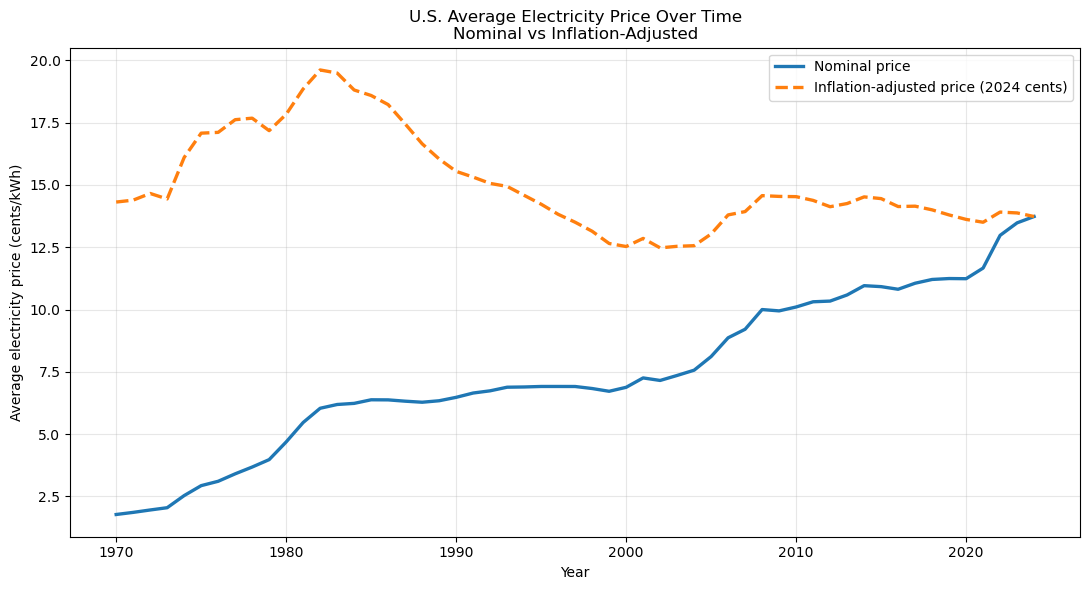

In [29]:
plt.figure(figsize=(11, 6))

plt.plot(
    price_inflation_df["Year"],
    price_inflation_df["Avg_Electricity_Price"],
    linewidth=2.4,
    label="Nominal price"
)

plt.plot(
    price_inflation_df["Year"],
    price_inflation_df["Real_Electricity_Price_2024_cents"],
    linewidth=2.4,
    linestyle="--",
    label="Inflation-adjusted price (2024 cents)"
)

plt.title("U.S. Average Electricity Price Over Time\nNominal vs Inflation-Adjusted")
plt.xlabel("Year")
plt.ylabel("Average electricity price (cents/kWh)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("us_electricity_price_nominal_vs_inflation_adjusted.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
ml_ep_df = (
    prod_df.merge(avg_price_table, on="Year", how="inner")
           .merge(cpi_yearly, on="Year", how="left")
           .sort_values("Year")
           .reset_index(drop=True)
)

ml_ep_df["Real_Electricity_Price"] = (
    ml_ep_df["Avg_Electricity_Price"] * (base_cpi / ml_ep_df["CPI"])
)

ml_ep_df = ml_ep_df.dropna(subset=["Year", "Avg_Electricity_Price", "CPI", "Real_Electricity_Price"]).copy()

print(ml_ep_df.shape)
print(ml_ep_df.head())
print(ml_ep_df.tail())
print(ml_ep_df.isnull().sum())

(54, 11)
   Year  Geothermal_Prod  Hydroelectric_Prod  Solar_Prod  Wind_Prod  \
0  1970             1869              919641           0          0   
1  1971             4957              941469           0          0   
2  1972             6707              939769           0          0   
3  1973             8368             1037971           0          0   
4  1974            11076             1034357           0          0   

   Biofuels_Prod  WoodWaste_Prod  Renewable_Production_Total  \
0            0.0       1430962.0                   2352472.0   
1            0.0       1432323.0                   2378749.0   
2            0.0       1503065.0                   2449541.0   
3            0.0       1529068.0                   2575407.0   
4            0.0       1539661.0                   2585094.0   

   Avg_Electricity_Price        CPI  Real_Electricity_Price  
0               1.772500  38.841667               14.315297  
1               1.857308  40.483333               14.39

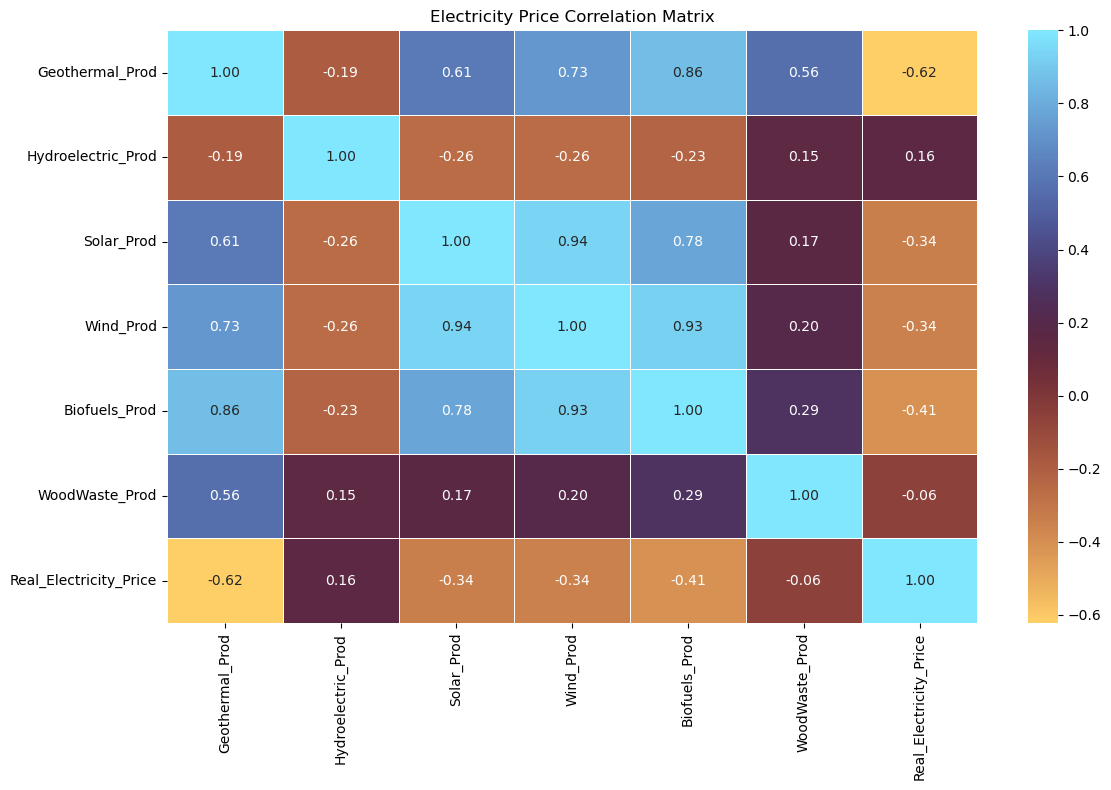

In [31]:
# Electrical Price Correlation Analysis

corr_ep_df = ml_ep_df.drop(columns=["Year", "Avg_Electricity_Price", "CPI", "Renewable_Production_Total"]).corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_ep_df,
    annot=True,
    fmt=".2f",
    cmap="managua",
    linewidths=0.5
)

plt.title("Electricity Price Correlation Matrix")
plt.tight_layout()

plt.savefig("ep_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
# Electricity price correlations
price_corr = corr_ep_df["Real_Electricity_Price"].sort_values(ascending=False)

print("\nCorrelation with Real_Electricity_Price:")
print(price_corr)


Correlation with Real_Electricity_Price:
Real_Electricity_Price    1.000000
Hydroelectric_Prod        0.160713
WoodWaste_Prod           -0.056006
Solar_Prod               -0.340784
Wind_Prod                -0.344687
Biofuels_Prod            -0.412231
Geothermal_Prod          -0.622512
Name: Real_Electricity_Price, dtype: float64


### C02 Levels

In [33]:
# ML CO2 Dataset

co2_df = emissions_df[
    (emissions_df["State"] == "US-TOTAL") &
    (emissions_df["Producer Type"] == "Total Electric Power Industry") &
    (emissions_df["Energy Source"] == "All Sources")
][["Year", "CO2\n(Metric Tons)"]].copy()

co2_df = co2_df.rename(columns={"CO2\n(Metric Tons)": "CO2_Total"})
co2_df["Year"] = pd.to_numeric(co2_df["Year"], errors="coerce")
co2_df["CO2_Total"] = pd.to_numeric(co2_df["CO2_Total"], errors="coerce")
co2_df = co2_df.dropna().sort_values("Year").reset_index(drop=True)
co2_df["Year"] = co2_df["Year"].astype(int)

co2_ml_df = (
    prod_df.merge(co2_df, on="Year", how="inner")
        .sort_values("Year")
        .reset_index(drop=True)
)

co2_ml_df = co2_ml_df.dropna().reset_index(drop=True)

print(co2_ml_df.shape)
print(co2_ml_df.head())
print(co2_ml_df.tail())
print(co2_ml_df.isnull().sum())

(34, 9)
   Year  Geothermal_Prod  Hydroelectric_Prod  Solar_Prod  Wind_Prod  \
0  1990            65478              986048       58040      10069   
1  1991            66863              863536       59819       9852   
2  1992            69783              957046       61682      10256   
3  1993            66221              887549       63410      11762   
4  1994            59747             1060561       64396      10796   

   Biofuels_Prod  WoodWaste_Prod  Renewable_Production_Total   CO2_Total  
0       110868.0       2626115.0                   3856618.0  1953698942  
1       128001.0       2653799.0                   3781870.0  1950465707  
2       145005.0       2786668.0                   4030440.0  1972275109  
3       169335.0       2736942.0                   3935219.0  2057052600  
4       188390.0       2839141.0                   4223031.0  2088138401  
    Year  Geothermal_Prod  Hydroelectric_Prod  Solar_Prod  Wind_Prod  \
29  2019           117716              9733

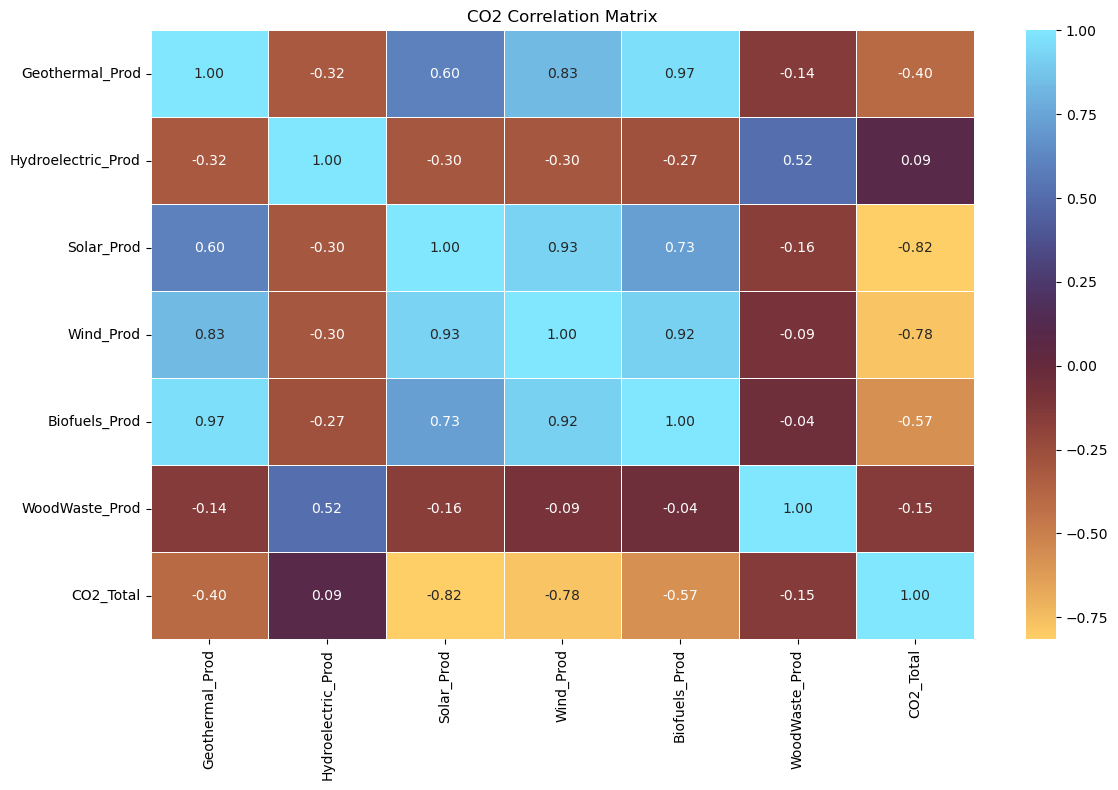

In [34]:
# CO2 Correlation Analysis

corr_co2_df = co2_ml_df.drop(columns=["Year", "Renewable_Production_Total"]).corr(numeric_only=True)


plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_co2_df,
    annot=True,
    fmt=".2f",
    cmap="managua",
    linewidths=0.5
)

plt.title("CO2 Correlation Matrix")
plt.tight_layout()
plt.savefig("CO2_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
# CO2 correlations
co2_corr = corr_co2_df["CO2_Total"].sort_values(ascending=False)

print("\nCorrelation with CO2_Total:")
print(co2_corr)


Correlation with CO2_Total:
CO2_Total             1.000000
Hydroelectric_Prod    0.089719
WoodWaste_Prod       -0.147920
Geothermal_Prod      -0.399347
Biofuels_Prod        -0.568732
Wind_Prod            -0.775886
Solar_Prod           -0.816244
Name: CO2_Total, dtype: float64


In [36]:
# ML Merged Dataset

ml_state_df = ( 
    prod_df.merge(cons_df, on="Year", how="inner") 
        .merge(avg_price_table, on="Year", how="inner") 
        .merge(state_price_table, on="Year", how="inner") 
        .merge(co2_source_df, on="Year", how="inner") 
        .merge(co2_state_df, on="Year", how="inner") 
        .sort_values("Year") 
        .reset_index(drop=True) 
)

print(ml_state_df.shape)
print(ml_state_df.head())
print(ml_state_df.tail())
print(ml_state_df.isnull().sum())

(15132, 75)
   Year  Geothermal_Prod  Hydroelectric_Prod  Solar_Prod  Wind_Prod  \
0  1990            65478              986048       58040      10069   
1  1990            65478              986048       58040      10069   
2  1990            65478              986048       58040      10069   
3  1990            65478              986048       58040      10069   
4  1990            65478              986048       58040      10069   

   Biofuels_Prod  WoodWaste_Prod  Renewable_Production_Total  Geothermal_Cons  \
0       110868.0       2626115.0                   3856618.0            62862   
1       110868.0       2626115.0                   3856618.0            62862   
2       110868.0       2626115.0                   3856618.0            62862   
3       110868.0       2626115.0                   3856618.0            62862   
4       110868.0       2626115.0                   3856618.0            62862   

   Hydroelectric_Cons  ...    VA    VT   WA    WI    WV    WY  Energy Sour

## ML Models


### Electricity Price Model

In [37]:
# ML Electricity Price Target

target = "Real_Electricity_Price"

train_df, test_df = train_test_split(
    ml_ep_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

test_years = test_df["Year"]

X_train = train_df.drop(
    columns=["Year", "Avg_Electricity_Price", "CPI", "Renewable_Production_Total", target],
    errors="ignore"
).select_dtypes(include=["number"])

X_test = test_df.drop(
    columns=["Year", "Avg_Electricity_Price", "CPI", "Renewable_Production_Total", target],
    errors="ignore"
).select_dtypes(include=["number"])

y_train = train_df[target]
y_test = test_df[target]

feature_cols = X_train.columns.tolist()

print("Target:", target)
print("Features:", feature_cols)

Target: Real_Electricity_Price
Features: ['Geothermal_Prod', 'Hydroelectric_Prod', 'Solar_Prod', 'Wind_Prod', 'Biofuels_Prod', 'WoodWaste_Prod']


In [38]:
models = {
    "LinearRegression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "LassoCV": make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=100000, random_state=42)),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42
    )
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    predictions[name] = y_test_pred

    train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
    test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })

results_df = pd.DataFrame(results).sort_values("Test RMSE").reset_index(drop=True)
print(results_df)

              Model       MAE  Train RMSE  Test RMSE  Train R2   Test R2
0      RandomForest  0.648713    0.255374   0.769453  0.980138  0.887538
1           LassoCV  1.031002    0.925651   1.192404  0.739052  0.729923
2  LinearRegression  1.055935    0.916149   1.211639  0.744381  0.721139
3             Ridge  1.032845    0.970518   1.242744  0.713142  0.706637


In [39]:
pred_df = pd.DataFrame({
    "Year": test_years.values,
    "Actual": y_test.values
})

for name, pred in predictions.items():
    pred_df[name] = pred

pred_df = pred_df.sort_values(by="Year").reset_index(drop=True)

print(pred_df)

    Year     Actual  LinearRegression      Ridge    LassoCV  RandomForest
0   1973  14.438997         15.339926  15.479813  15.437899     15.544660
1   1975  17.080853         15.047897  15.256850  15.160655     16.047080
2   1982  19.617801         17.664225  17.251260  17.546451     18.279339
3   1983  19.494317         18.051890  17.527861  17.877265     18.454153
4   1987  17.452848         18.239424  17.604544  17.948313     17.362552
5   1989  16.043225         15.589972  15.551235  15.578036     15.263982
6   2002  12.476062         12.785699  13.339731  12.998298     12.756468
7   2014  14.522313         15.709786  15.146325  15.435987     13.861630
8   2018  14.001750         15.442924  14.990473  15.273083     14.257056
9   2019  13.797691         14.730140  14.626395  14.715412     14.080073
10  2022  13.912616         13.737786  13.697937  13.764719     13.643148


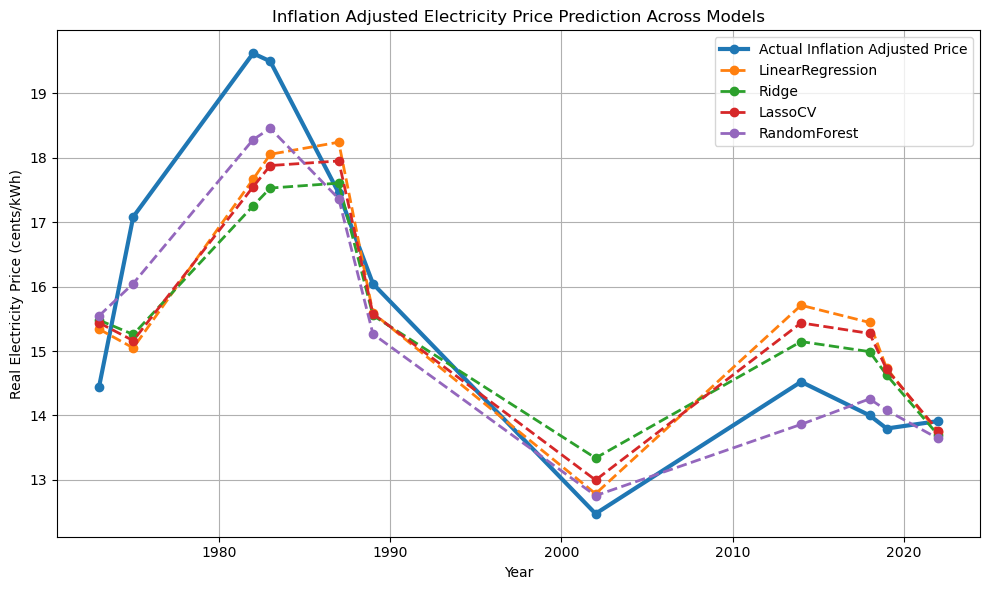

In [40]:
plt.figure(figsize=(10, 6))

# Actual real electricity price
plt.plot(
    pred_df["Year"],
    pred_df["Actual"],
    marker="o",
    linewidth=3,
    label="Actual Inflation Adjusted Price"
)

# Predictions from all models
for name in predictions:
    plt.plot(
        pred_df["Year"],
        pred_df[name],
        marker="o",
        linewidth=2,
        linestyle="--",
        label=name
    )

plt.title("Inflation Adjusted Electricity Price Prediction Across Models")
plt.xlabel("Year")
plt.ylabel("Real Electricity Price (cents/kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("real_ep_prediction_models.png", dpi=300, bbox_inches="tight")
plt.show()

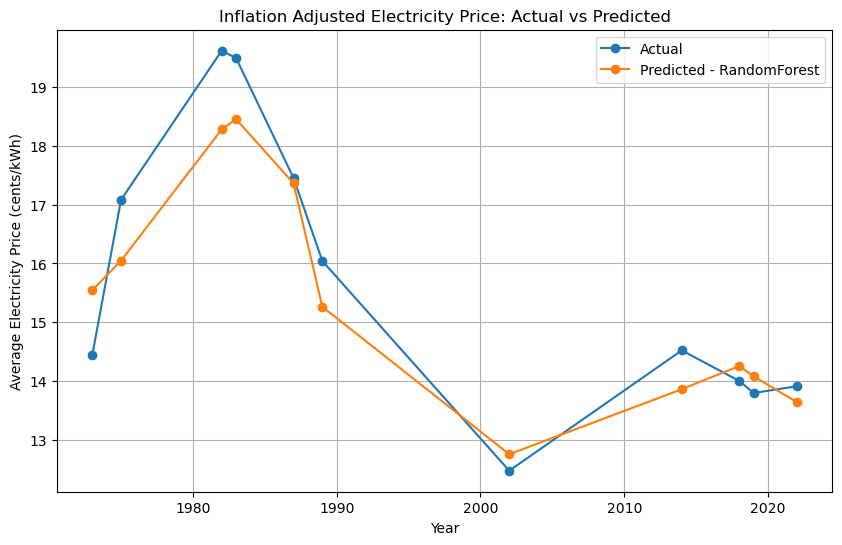

In [41]:
best_model_name = results_df.loc[0, "Model"]

plt.figure(figsize=(10, 6))
plt.plot(pred_df["Year"], pred_df["Actual"], marker="o", label="Actual")
plt.plot(pred_df["Year"], pred_df[best_model_name], marker="o", label=f"Predicted - {best_model_name}")
plt.title("Inflation Adjusted Electricity Price: Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("Average Electricity Price (cents/kWh)")
plt.legend()
plt.grid(True)

plt.savefig("inflation_adjusted_electricity_price.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
coef_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    estimator = model[-1]
    
    if hasattr(estimator, "coef_"):
        coef_df = pd.DataFrame({
            "Feature": feature_cols,
            "Coefficient": estimator.coef_
        }).sort_values("Coefficient", ascending=False).reset_index(drop=True)
        
        coef_results[name] = coef_df
    
    elif hasattr(estimator, "feature_importances_"):
        coef_df = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": estimator.feature_importances_
        }).sort_values("Importance", ascending=False).reset_index(drop=True)
        
        coef_results[name] = coef_df

for name, df in coef_results.items():
    print(f"\n{name}")
    print(df)


LinearRegression
              Feature  Coefficient
0       Biofuels_Prod     2.798910
1      WoodWaste_Prod     1.467812
2  Hydroelectric_Prod    -0.333955
3          Solar_Prod    -0.351808
4           Wind_Prod    -0.413841
5     Geothermal_Prod    -3.851847

Ridge
              Feature  Coefficient
0       Biofuels_Prod     1.414775
1      WoodWaste_Prod     1.120319
2           Wind_Prod     0.544324
3  Hydroelectric_Prod    -0.246429
4          Solar_Prod    -0.673924
5     Geothermal_Prod    -2.889711

LassoCV
              Feature  Coefficient
0       Biofuels_Prod     2.216557
1      WoodWaste_Prod     1.324175
2           Wind_Prod    -0.000000
3  Hydroelectric_Prod    -0.279122
4          Solar_Prod    -0.466370
5     Geothermal_Prod    -3.477343

RandomForest
              Feature  Importance
0           Wind_Prod    0.532426
1  Hydroelectric_Prod    0.187533
2          Solar_Prod    0.115441
3      WoodWaste_Prod    0.096706
4     Geothermal_Prod    0.057654
5       Biofu

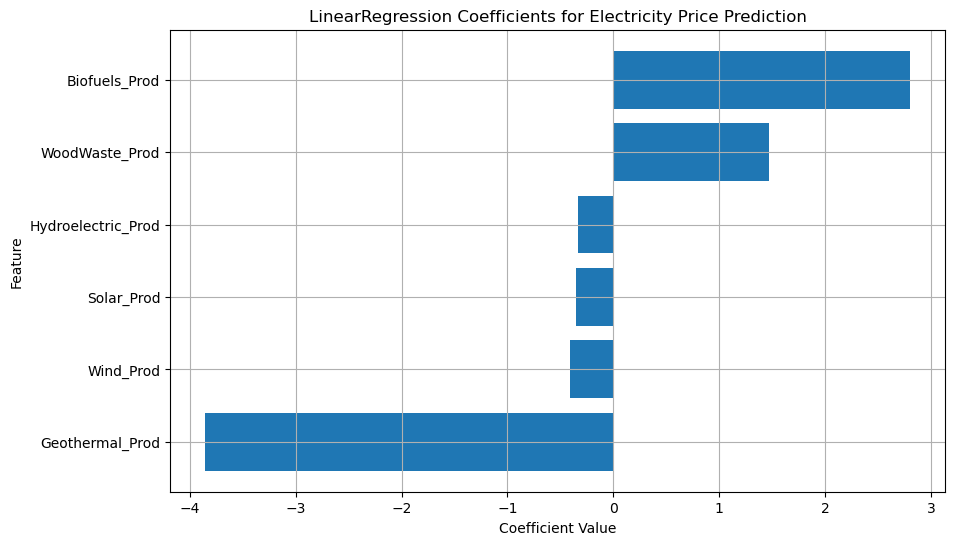

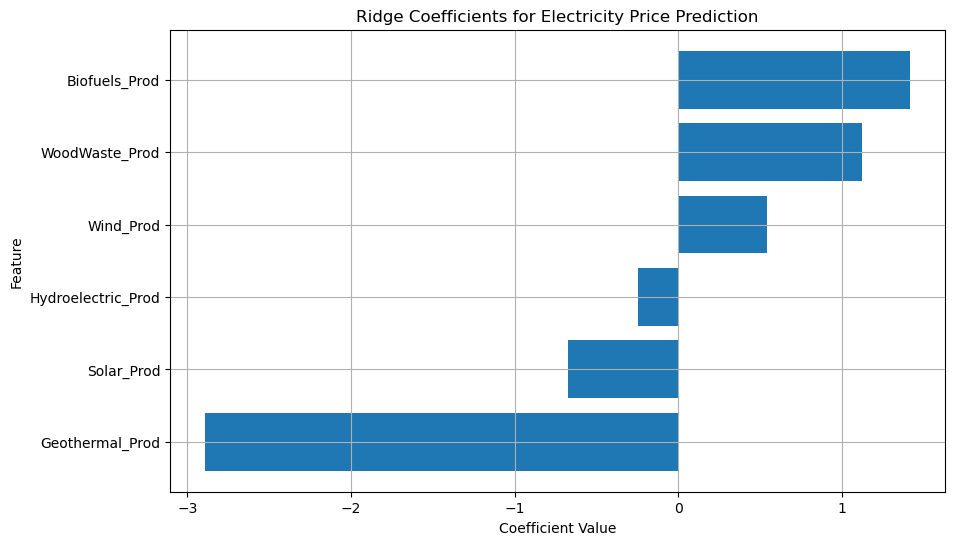

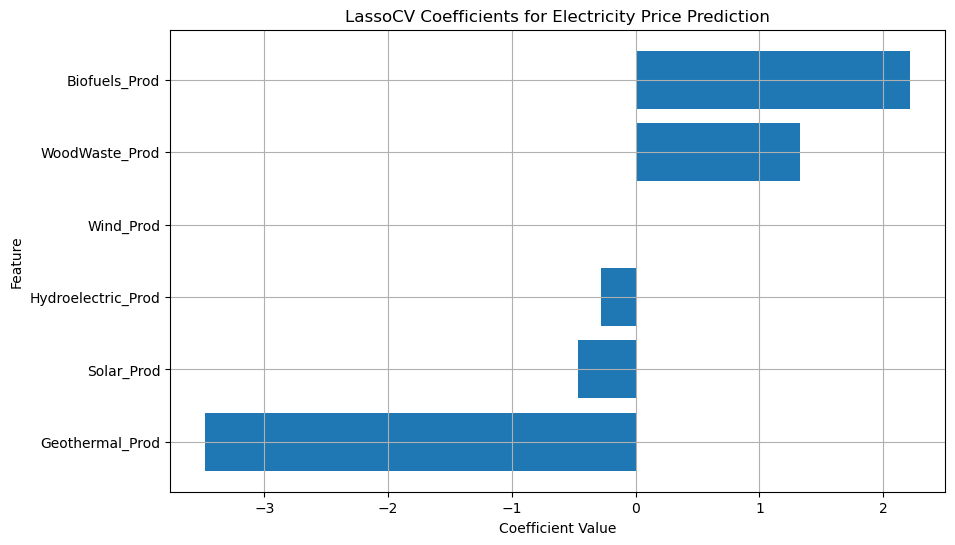

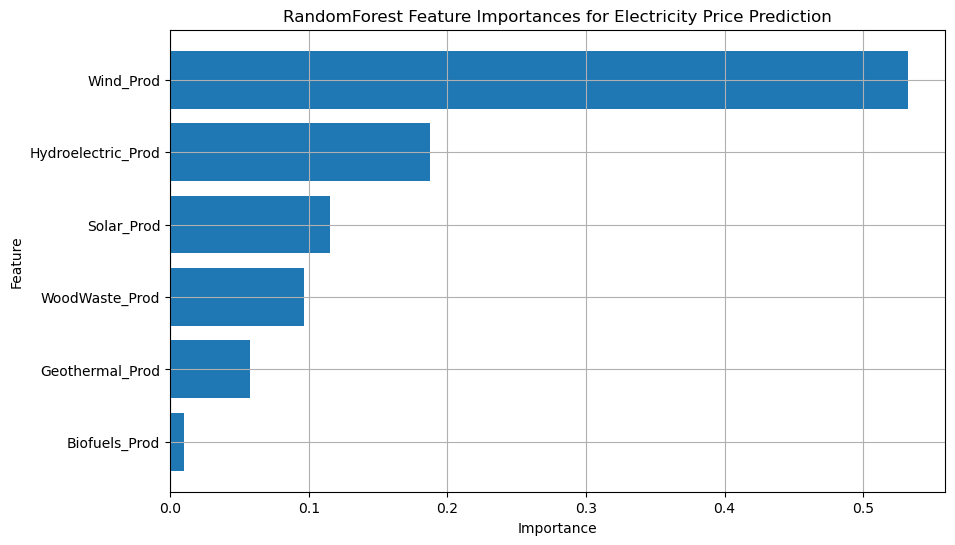

In [43]:
for name, model in models.items():
    model.fit(X_train, y_train)

for name, model in models.items():
    estimator = model[-1]
    
    if hasattr(estimator, "coef_"):
        coef_df = pd.DataFrame({
            "Feature": feature_cols,
            "Value": estimator.coef_
        }).sort_values("Value", ascending=True)

        plt.figure(figsize=(10, 6))
        plt.barh(coef_df["Feature"], coef_df["Value"])
        plt.title(f"{name} Coefficients for Electricity Price Prediction")
        plt.xlabel("Coefficient Value")
        plt.ylabel("Feature")
        plt.grid(True)
        plt.show()

    elif hasattr(estimator, "feature_importances_"):
        importance_df = pd.DataFrame({
            "Feature": feature_cols,
            "Value": estimator.feature_importances_
        }).sort_values("Value", ascending=True)

        plt.figure(figsize=(10, 6))
        plt.barh(importance_df["Feature"], importance_df["Value"])
        plt.title(f"{name} Feature Importances for Electricity Price Prediction")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.grid(True)

        plt.savefig(f"{name}_feature_importances_ep.png", dpi=300, bbox_inches="tight")
        plt.show()

### CO2 Model

In [44]:
target = "CO2_Total"

X = co2_ml_df.drop(columns=["Year", "Renewable_Production_Total", target], errors="ignore")
X = X.select_dtypes(include=["number"])
y = co2_ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

test_years = co2_ml_df.loc[X_test.index, "Year"]

feature_cols = X_train.columns.tolist()

print("Features:", feature_cols)

Features: ['Geothermal_Prod', 'Hydroelectric_Prod', 'Solar_Prod', 'Wind_Prod', 'Biofuels_Prod', 'WoodWaste_Prod']


In [45]:
models = {
    "LinearRegression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "LassoCV": make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=100000, random_state=42)),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42
    )
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    
    predictions[name] = pred_test
    
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred_test),
        "Train RMSE": mean_squared_error(y_train, pred_train) ** 0.5,
        "Test RMSE": mean_squared_error(y_test, pred_test) ** 0.5,
        "Train R2": r2_score(y_train, pred_train),
        "Test R2": r2_score(y_test, pred_test),
    })

results_df = pd.DataFrame(results).sort_values("Test RMSE").reset_index(drop=True)
print(results_df.to_string())

              Model           MAE    Train RMSE     Test RMSE  Train R2   Test R2
0      RandomForest  8.308757e+07  5.808689e+07  9.256359e+07  0.964562  0.829160
1  LinearRegression  9.098157e+07  1.207961e+08  1.160018e+08  0.846742  0.731689
2           LassoCV  1.018393e+08  1.267702e+08  1.193912e+08  0.831208  0.715781
3             Ridge  1.060057e+08  1.353272e+08  1.227524e+08  0.807652  0.699552


In [46]:
pred_co2_df = pd.DataFrame({
    "Year": test_years.values,
    "Actual_CO2": y_test.values
})

pred_co2_df = pred_co2_df.sort_values(by="Year").reset_index(drop=True)

for name, pred in predictions.items():
    pred_co2_df[name] = pred

print(pred_co2_df.to_string())

   Year  Actual_CO2  LinearRegression         Ridge       LassoCV  RandomForest
0  1998  2351599517      2.422099e+09  2.360763e+09  2.378185e+09  2.452703e+09
1  2005  2543838163      2.512756e+09  2.463774e+09  2.478058e+09  2.406360e+09
2  2009  2269507628      1.917573e+09  1.950937e+09  1.946983e+09  1.843171e+09
3  2011  2287070730      1.961415e+09  1.985182e+09  1.983275e+09  1.985104e+09
4  2014  2168284275      2.242045e+09  2.221588e+09  2.232994e+09  2.223947e+09
5  2016  1928400912      2.181394e+09  2.108567e+09  2.132988e+09  2.078159e+09
6  2017  1849749801      2.335453e+09  2.304072e+09  2.319732e+09  2.214505e+09


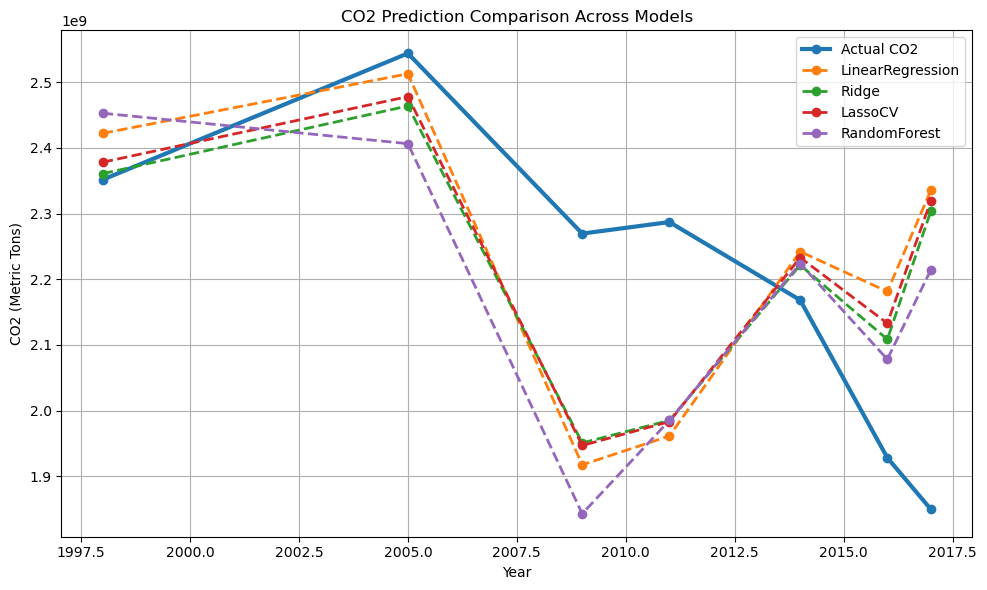

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(pred_co2_df["Year"], pred_co2_df["Actual_CO2"], marker="o", linewidth=3, label="Actual CO2")

for name in predictions:
    plt.plot(pred_co2_df["Year"], pred_co2_df[name], marker="o", linewidth=2, linestyle="--", label=name)

plt.title("CO2 Prediction Comparison Across Models")
plt.xlabel("Year")
plt.ylabel("CO2 (Metric Tons)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(f"co2_prediction_models.png", dpi=300, bbox_inches="tight")
plt.show()

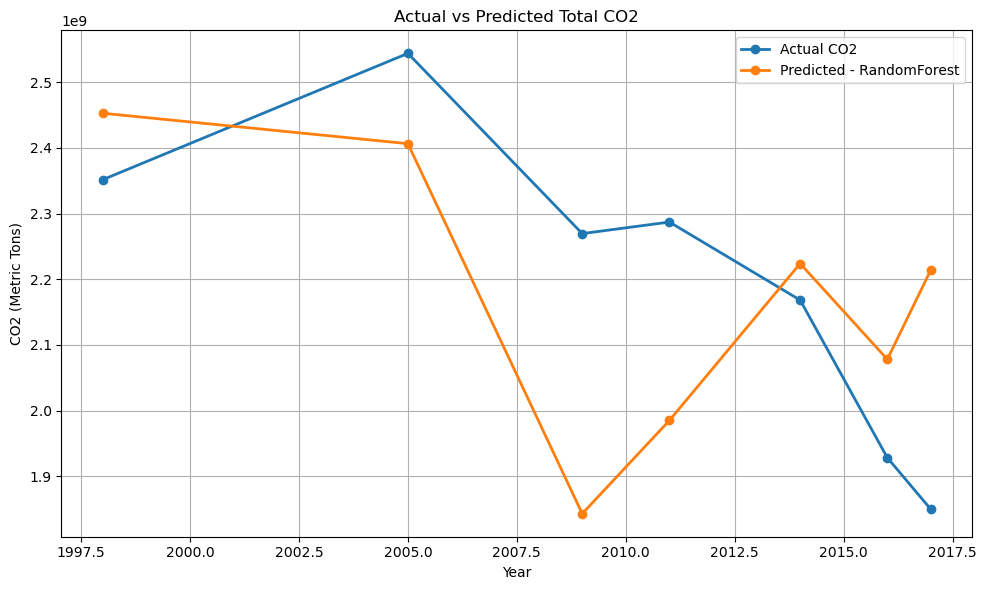

In [48]:
best_model_name = results_df.loc[0, "Model"]

plt.figure(figsize=(10, 6))
plt.plot(pred_co2_df["Year"], pred_co2_df["Actual_CO2"], marker="o", linewidth=2, label="Actual CO2")
plt.plot(pred_co2_df["Year"], pred_co2_df[best_model_name], marker="o", linewidth=2, label=f"Predicted - {best_model_name}")

plt.title("Actual vs Predicted Total CO2")
plt.xlabel("Year")
plt.ylabel("CO2 (Metric Tons)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(f"actual_vs_predicted_co2.png", dpi=300, bbox_inches="tight")
plt.show()

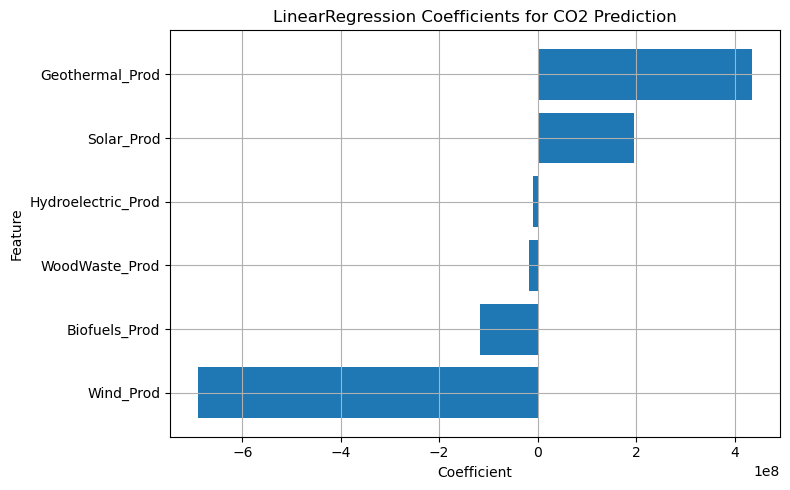

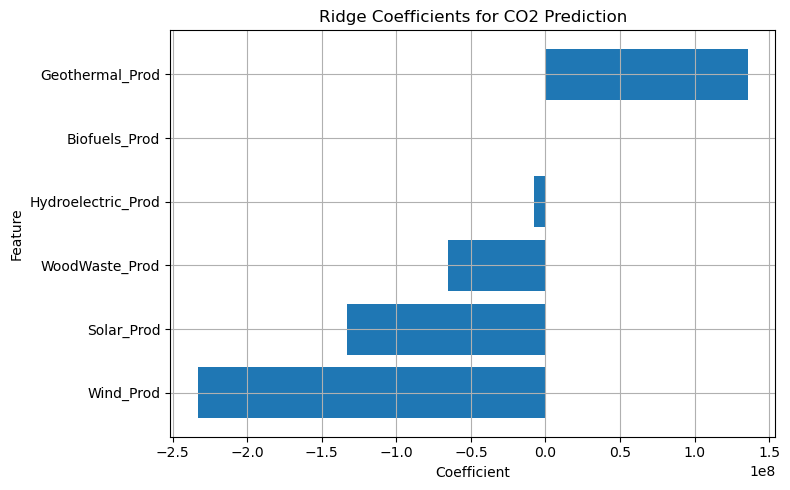

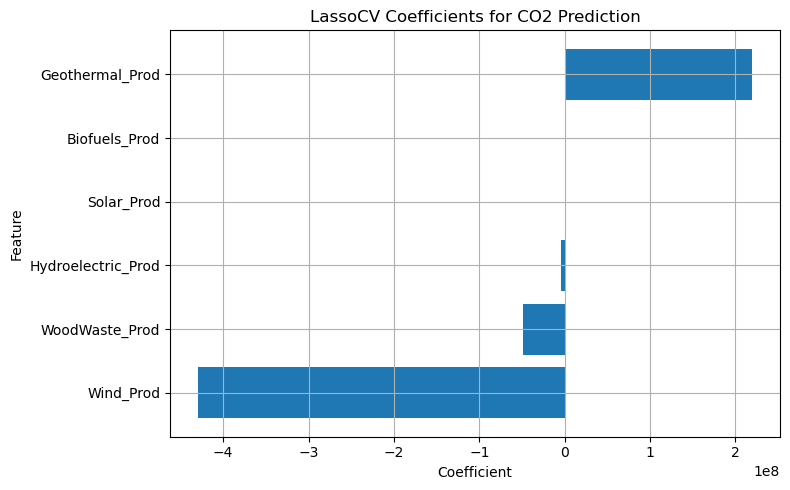

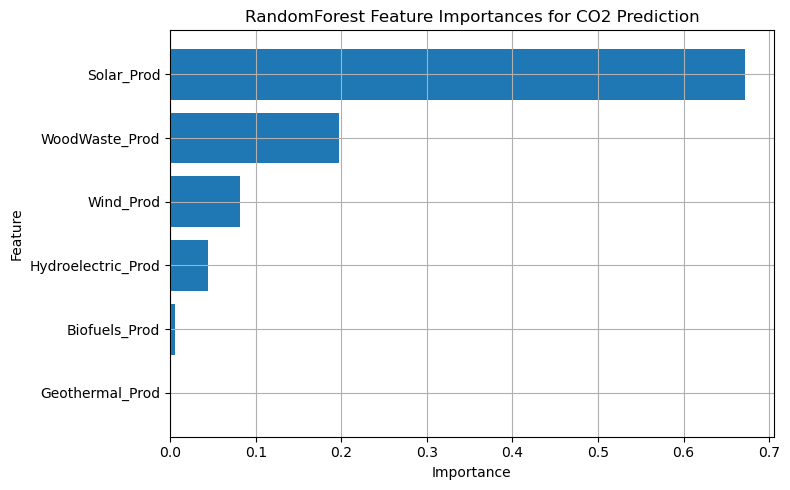

In [49]:
for name, model in models.items():
    estimator = model[-1]
    
    if hasattr(estimator, "coef_"):
        coef_df = pd.DataFrame({
            "Feature": feature_cols,
            "Value": estimator.coef_
        }).sort_values("Value", ascending=True)
        
        plt.figure(figsize=(8, 5))
        plt.barh(coef_df["Feature"], coef_df["Value"])
        plt.title(f"{name} Coefficients for CO2 Prediction")
        plt.xlabel("Coefficient")
        plt.ylabel("Feature")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
    elif hasattr(estimator, "feature_importances_"):
        imp_df = pd.DataFrame({
            "Feature": feature_cols,
            "Value": estimator.feature_importances_
        }).sort_values("Value", ascending=True)
        
        plt.figure(figsize=(8, 5))
        plt.barh(imp_df["Feature"], imp_df["Value"])
        plt.title(f"{name} Feature Importances for CO2 Prediction")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.grid(True)
        plt.tight_layout()

        plt.savefig(f"{name}_feature_importances_co2.png", dpi=300, bbox_inches="tight")
        plt.show()

## Forecast to 2035

In [50]:
from sklearn.base import clone

future_years = pd.DataFrame({
    "Year": range(int(prod_df["Year"].max()) + 1, 2036)
})


def forecast_future_features_from_existing_data(history_df, future_years_df, feature_cols):
    """
    Forecast each input feature to 2035 using historical production data.
    This creates the future X values needed by the already defined ML models.
    """
    future_X = pd.DataFrame(index=future_years_df.index)

    for col in feature_cols:
        hist = history_df[["Year", col]].dropna().sort_values("Year")

        # Simple trend model for future feature values
        feature_model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0)
        )

        feature_model.fit(hist[["Year"]], hist[col])
        future_X[col] = feature_model.predict(future_years_df[["Year"]])

        # Production values should not be negative
        future_X[col] = future_X[col].clip(lower=0)

    return future_X[feature_cols]

In [51]:
# ML Electricity Price Forecast

target = "Real_Electricity_Price"

train_df, test_df = train_test_split(
    ml_ep_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

test_years = test_df["Year"]

X_train = train_df.drop(
    columns=["Year", "Avg_Electricity_Price", "CPI", target],
    errors="ignore"
).select_dtypes(include=["number"])

X_test = test_df.drop(
    columns=["Year", "Avg_Electricity_Price", "CPI", target],
    errors="ignore"
).select_dtypes(include=["number"])

y_train = train_df[target]
y_test = test_df[target]

feature_cols = X_train.columns.tolist()

print("Electricity Price Target:", target)
print("Electricity Price Features:", feature_cols)

models = {
    "LinearRegression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "LassoCV": make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=100000, random_state=42)),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42
    )
}

results = []
predictions = {}
trained_price_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    predictions[name] = y_test_pred
    trained_price_models[name] = model

    train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
    test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })

price_results_df = pd.DataFrame(results).sort_values("Test RMSE").reset_index(drop=True)
print("\nElectricity Price Model Results")
print(price_results_df)

best_price_model_name = price_results_df.loc[0, "Model"]
best_price_model = trained_price_models[best_price_model_name]

future_price_X = forecast_future_features_from_existing_data(
    ml_ep_df,
    future_years,
    feature_cols
)

future_price_predictions = best_price_model.predict(future_price_X)

cpi_trend_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

cpi_history = cpi_yearly[["Year", "CPI"]].dropna().sort_values("Year")
cpi_trend_model.fit(cpi_history[["Year"]], cpi_history["CPI"])

future_cpi = cpi_trend_model.predict(future_years[["Year"]])

price_forecast_df = future_years.copy()
price_forecast_df["Predicted_CPI"] = future_cpi
price_forecast_df["Predicted_Real_Electricity_Price"] = future_price_predictions

# Real price was calculated earlier as: Real_Electricity_Price = Avg_Electricity_Price * (base_cpi / CPI)
# Therefore: Nominal_Electricity_Price = Real_Electricity_Price * (CPI / base_cpi)
price_forecast_df["Predicted_Nominal_Electricity_Price"] = (
    price_forecast_df["Predicted_Real_Electricity_Price"]
    * (price_forecast_df["Predicted_CPI"] / base_cpi)
)

price_forecast_df["Electricity_Price_Model"] = best_price_model_name

print("\nElectricity Price Forecast to 2035")
print(price_forecast_df)

Electricity Price Target: Real_Electricity_Price
Electricity Price Features: ['Geothermal_Prod', 'Hydroelectric_Prod', 'Solar_Prod', 'Wind_Prod', 'Biofuels_Prod', 'WoodWaste_Prod', 'Renewable_Production_Total']

Electricity Price Model Results
              Model       MAE  Train RMSE  Test RMSE  Train R2   Test R2
0      RandomForest  0.675928    0.268788   0.817977  0.977997  0.872907
1           LassoCV  1.031002    0.925651   1.192405  0.739051  0.729922
2  LinearRegression  1.055935    0.916149   1.211639  0.744381  0.721139
3             Ridge  1.036402    0.964755   1.240169  0.716539  0.707852

Electricity Price Forecast to 2035
    Year  Predicted_CPI  Predicted_Real_Electricity_Price  \
0   2024     279.164395                         14.093502   
1   2025     283.495010                         14.069559   
2   2026     287.825626                         14.068356   
3   2027     292.156242                         14.039115   
4   2028     296.486858                         14

In [52]:
# ML CO2 Forecast

target = "CO2_Total"

X = co2_ml_df.drop(columns=["Year", target], errors="ignore")
X = X.select_dtypes(include=["number"])
y = co2_ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

test_years = co2_ml_df.loc[X_test.index, "Year"]
feature_cols = X_train.columns.tolist()

print("\nCO2 Target:", target)
print("CO2 Features:", feature_cols)

models = {
    "LinearRegression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "LassoCV": make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=100000, random_state=42)),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42
    )
}

results = []
predictions = {}
trained_co2_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    predictions[name] = pred_test
    trained_co2_models[name] = model

    train_rmse = mean_squared_error(y_train, pred_train) ** 0.5
    test_rmse = mean_squared_error(y_test, pred_test) ** 0.5
    train_r2 = r2_score(y_train, pred_train)
    test_r2 = r2_score(y_test, pred_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred_test),
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })

co2_results_df = pd.DataFrame(results).sort_values("Test RMSE").reset_index(drop=True)
print("\nCO2 Model Results")
print(co2_results_df)

best_co2_model_name = co2_results_df.loc[0, "Model"]
best_co2_model = trained_co2_models[best_co2_model_name]

future_co2_X = forecast_future_features_from_existing_data(
    co2_ml_df,
    future_years,
    feature_cols
)

future_co2_predictions = best_co2_model.predict(future_co2_X)

co2_forecast_df = future_years.copy()
co2_forecast_df["Predicted_CO2_Total"] = future_co2_predictions
co2_forecast_df["CO2_Model"] = best_co2_model_name

print("\nCO2 Forecast to 2035")
print(co2_forecast_df)


CO2 Target: CO2_Total
CO2 Features: ['Geothermal_Prod', 'Hydroelectric_Prod', 'Solar_Prod', 'Wind_Prod', 'Biofuels_Prod', 'WoodWaste_Prod', 'Renewable_Production_Total']

CO2 Model Results
              Model           MAE    Train RMSE     Test RMSE  Train R2  \
0      RandomForest  7.722932e+07  5.810745e+07  8.883768e+07  0.964537   
1  LinearRegression  9.098157e+07  1.207961e+08  1.160018e+08  0.846742   
2           LassoCV  1.018413e+08  1.267696e+08  1.193938e+08  0.831210   
3             Ridge  1.036482e+08  1.349054e+08  1.208427e+08  0.808850   

    Test R2  
0  0.842637  
1  0.731689  
2  0.715769  
3  0.708828  

CO2 Forecast to 2035
    Year  Predicted_CO2_Total     CO2_Model
0   2024         1.676187e+09  RandomForest
1   2025         1.662456e+09  RandomForest
2   2026         1.655338e+09  RandomForest
3   2027         1.647480e+09  RandomForest
4   2028         1.645915e+09  RandomForest
5   2029         1.645622e+09  RandomForest
6   2030         1.645034e+09  Ran

In [53]:
# Combined forecast table

forecast_2035 = price_forecast_df.merge(co2_forecast_df, on="Year", how="inner")
print("\nCombined Forecast to 2035")
print(forecast_2035)

forecast_2035.to_csv("2035_Forecast.csv", index=False)


Combined Forecast to 2035
    Year  Predicted_CPI  Predicted_Real_Electricity_Price  \
0   2024     279.164395                         14.093502   
1   2025     283.495010                         14.069559   
2   2026     287.825626                         14.068356   
3   2027     292.156242                         14.039115   
4   2028     296.486858                         14.037472   
5   2029     300.817474                         14.037472   
6   2030     305.148090                         14.033634   
7   2031     309.478706                         14.028978   
8   2032     313.809322                         14.028978   
9   2033     318.139938                         14.003633   
10  2034     322.470554                         14.004498   
11  2035     326.801169                         13.979919   

    Predicted_Nominal_Electricity_Price Electricity_Price_Model  \
0                             12.542005            RandomForest   
1                             12.714928      

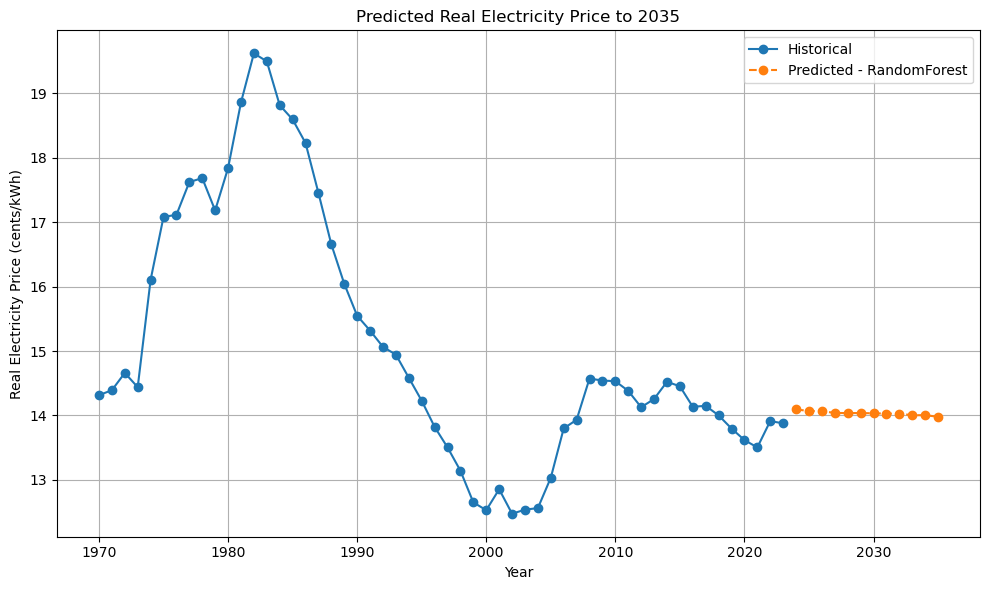

In [54]:
# Inflation adjusted electricity price forecast

plt.figure(figsize=(10, 6))
plt.plot(ml_ep_df["Year"], ml_ep_df["Real_Electricity_Price"], marker="o", label="Historical")
plt.plot(
    forecast_2035["Year"],
    forecast_2035["Predicted_Real_Electricity_Price"],
    marker="o",
    linestyle="--",
    label=f"Predicted - {best_price_model_name}"
)
plt.title("Predicted Real Electricity Price to 2035")
plt.xlabel("Year")
plt.ylabel("Real Electricity Price (cents/kWh)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("inflation_adjusted_ep_to_2035.png", dpi=300, bbox_inches="tight")
plt.show()

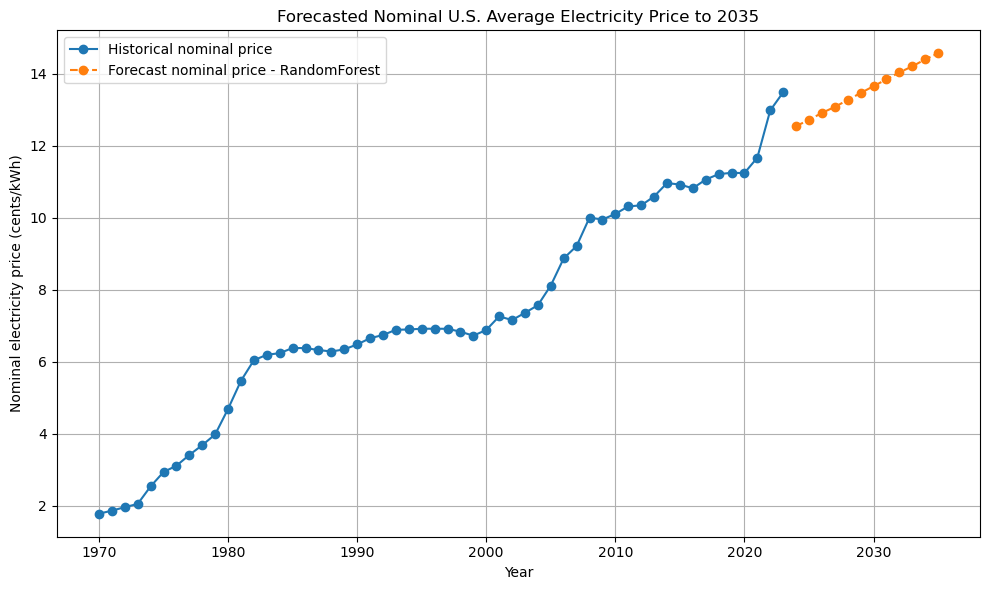

In [55]:
# Nominal electricity price forecast

plt.figure(figsize=(10, 6))
plt.plot(
    ml_ep_df["Year"],
    ml_ep_df["Avg_Electricity_Price"],
    marker="o",
    label="Historical nominal price"
)
plt.plot(
    forecast_2035["Year"],
    forecast_2035["Predicted_Nominal_Electricity_Price"],
    marker="o",
    linestyle="--",
    label=f"Forecast nominal price - {best_price_model_name}"
)

plt.title("Forecasted Nominal U.S. Average Electricity Price to 2035")
plt.xlabel("Year")
plt.ylabel("Nominal electricity price (cents/kWh)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("nominal_ep_to_2035.png", dpi=300, bbox_inches="tight")
plt.show()

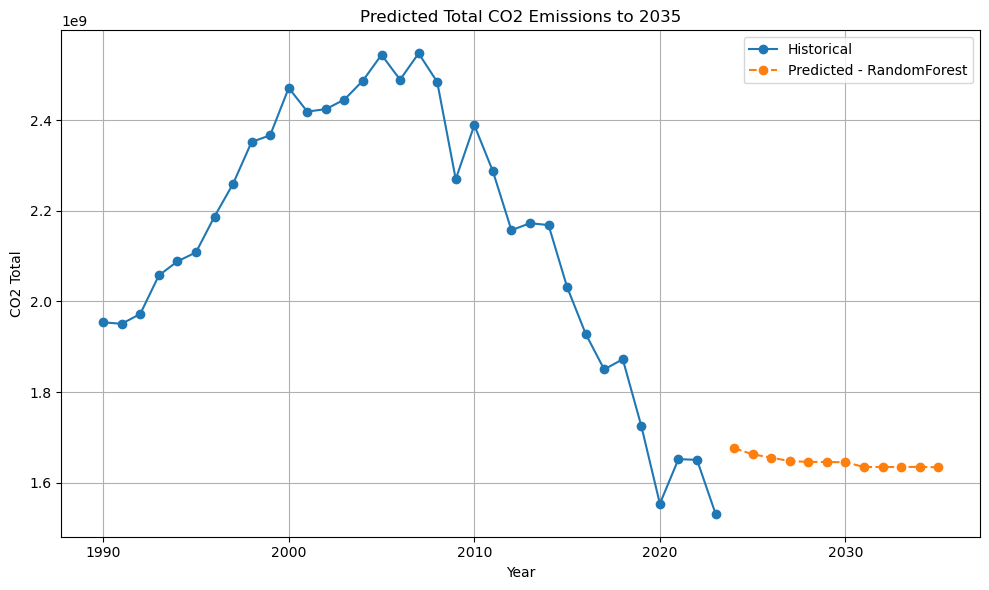

In [56]:
# CO2 level forecast

plt.figure(figsize=(10, 6))
plt.plot(co2_ml_df["Year"], co2_ml_df["CO2_Total"], marker="o", label="Historical")
plt.plot(
    forecast_2035["Year"],
    forecast_2035["Predicted_CO2_Total"],
    marker="o",
    linestyle="--",
    label=f"Predicted - {best_co2_model_name}"
)
plt.title("Predicted Total CO2 Emissions to 2035")
plt.xlabel("Year")
plt.ylabel("CO2 Total")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("co2_to_2035.png", dpi=300, bbox_inches="tight")
plt.show()